# URL Multiclass — Préprocessing, décision de split et baseline

Ce notebook couvre la première expérience ML complète sur le dataset URL multiclasses.

## Objectifs

1. charger et auditer le snapshot ML depuis PostgreSQL ;
2. vérifier le contrat des **13 features du Feature Set V1** ;
3. analyser valeurs manquantes, distributions, outliers et corrélations ;
4. étudier les transformations `log1p` candidates sans les imposer ;
5. résoudre le problème des `group_key` multi-labels par quarantaine ;
6. analyser la distribution temporelle de PhishTank et URLhaus ;
7. décider une stratégie de split reproductible ;
8. construire un split **stratifié + group-aware** ;
9. équilibrer uniquement le train en conservant des groupes complets ;
10. entraîner un baseline simple ;
11. mesurer ses performances sur un test laissé intact.

## Règles de sécurité et de qualité

- aucune URL brute n'est chargée ou affichée ;
- aucun `group_key`, hostname ou hash individuel n'est exposé dans les sorties ;
- aucune écriture n'est effectuée dans PostgreSQL ;
- le test n'est jamais utilisé pour ajuster le preprocessing ou les paramètres du modèle ;
- toute transformation apprenant des statistiques est ajustée uniquement sur le train ;
- la complexité du pipeline reste volontairement faible et reproductible.

> Le snapshot PostgreSQL reste la source de vérité. Les splits construits ici sont en mémoire et ne sont pas persistés tant que la stratégie et le baseline ne sont pas validés.

## 0. Pré-requis et reproductibilité

Le notebook suppose que PostgreSQL est accessible via `INGESTION_DATABASE_URL` dans le fichier `.env` du projet.

Les variables d'environnement sont chargées explicitement avec `python-dotenv`.

Les dépendances d'EDA et de ML ne sont pas installées automatiquement depuis le notebook. L'environnement doit fournir :

- pandas ;
- numpy ;
- matplotlib ;
- SQLAlchemy ;
- scikit-learn.

Le seed commun aux opérations de split et de balancing est fixé à `42`.

La connexion PostgreSQL reste **read-only** pendant toute l'EDA. Une fois les données chargées, l'entraînement se poursuit uniquement en mémoire.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

from dotenv import load_dotenv


def find_project_root() -> Path:
    """Retrouve la racine du dépôt sans dépendre du répertoire de lancement."""
    current = Path.cwd().resolve()

    for candidate in (current, *current.parents):
        if (
            (candidate / "application").is_dir()
            and (candidate / "infrastructure").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Impossible de retrouver la racine du projet. "
        "Lancer Jupyter depuis le dépôt threat-intelligence-platform."
    )


PROJECT_ROOT = find_project_root()
ENV_FILE = PROJECT_ROOT / ".env"

load_dotenv(
    dotenv_path=ENV_FILE,
    override=False,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if not os.environ.get("INGESTION_DATABASE_URL"):
    raise RuntimeError(
        "INGESTION_DATABASE_URL n'est pas définie. "
        "Vérifier le fichier .env sans afficher sa valeur dans le notebook."
    )

print("Project root: détecté")
print("INGESTION_DATABASE_URL: définie (valeur masquée)")

Project root: détecté
INGESTION_DATABASE_URL: définie (valeur masquée)


In [2]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display
    from sqlalchemy import text
except ImportError as exc:
    raise RuntimeError(
        "Dépendances EDA manquantes. Installer explicitement "
        "pandas, numpy et matplotlib dans l'environnement ML du projet."
    ) from exc

from infrastructure.persistence.sqlalchemy import create_ingestion_engine

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

RANDOM_SEED = 42

DATASET_NAME = "url_multiclass_pool"
DATASET_VERSION = "2026-08-12-v1"
EXPECTED_FEATURE_SET_VERSION = "2.0.0"
EXPECTED_LABELS = {"benign", "phishing", "malware"}
THREAT_SOURCES = ("phishtank", "urlhaus")

FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

INTEGER_LIKE_FEATURES = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]

print(f"Seed futur split: {RANDOM_SEED}")
print(f"Snapshot: {DATASET_NAME}/{DATASET_VERSION}")
print(f"Feature set attendu: {EXPECTED_FEATURE_SET_VERSION}")
print(f"Nombre de features attendues: {len(FEATURE_COLUMNS)}")

Seed futur split: 42
Snapshot: url_multiclass_pool/2026-08-12-v1
Feature set attendu: 2.0.0
Nombre de features attendues: 13


## 1. Charger et vérifier le snapshot ML

Nous commençons par vérifier les métadonnées du snapshot. Le notebook échoue volontairement si le snapshot n'existe pas ou si son `feature_set_version` ne correspond pas au contrat attendu.

Le chargement principal reste **read-only**.

In [3]:
engine = create_ingestion_engine()

snapshot_query = text(
    """
    SELECT
        id::text AS dataset_id,
        name,
        version,
        status,
        projection_version,
        feature_set_version,
        class_targets,
        label_mapping,
        created_at,
        frozen_at
    FROM ml.dataset_snapshot
    WHERE name = :dataset_name
      AND version = :dataset_version
    """
)

with engine.connect() as connection:
    snapshot_df = pd.read_sql_query(
        snapshot_query,
        connection,
        params={
            "dataset_name": DATASET_NAME,
            "dataset_version": DATASET_VERSION,
        },
    )

if len(snapshot_df) != 1:
    raise RuntimeError(
        f"Snapshot introuvable ou non unique: {DATASET_NAME}/{DATASET_VERSION}. "
        "Vérifier DATASET_VERSION avant de continuer."
    )

snapshot_feature_version = snapshot_df.loc[0, "feature_set_version"]

if snapshot_feature_version != EXPECTED_FEATURE_SET_VERSION:
    raise RuntimeError(
        "Feature set incompatible: "
        f"snapshot={snapshot_feature_version!r}, "
        f"attendu={EXPECTED_FEATURE_SET_VERSION!r}."
    )

display(snapshot_df)

,dataset_id,name,version,status,projection_version,feature_set_version,class_targets,label_mapping,created_at,frozen_at
0,bc4e86e5-baf8-4bf3-b73c-e70cae3527d6,url_multiclass_pool,2026-08-12-v1,draft,1.0.0,2.0.0,"{'benign': 58668, 'malware': 29925, 'phishing'...","{'benign': 0, 'malware': 2, 'phishing': 1}",2026-08-12 16:57:36.639459+00:00,None


### Interprétation du snapshot chargé

Le snapshot chargé correspond bien au pool multiclasses destiné à l'étude ML.

Observations :

- le snapshot contient `155 818` observations ;
- son `feature_set_version` est `2.0.0`, conformément au Feature Set V1 actuellement persisté ;
- son statut est encore `draft` ;
- aucun `frozen_at` n'est défini.

Ce statut est cohérent avec l'étape actuelle : aucune stratégie de split n'a encore été validée ni persistée.

Le snapshot doit rester en `draft` tant que les audits de qualité, de groupes et de distribution temporelle ne sont pas terminés.

## 2. Charger le dataset complet dans pandas

Le `DataFrame` contient **tous les membres du snapshot**, mais nous ne chargeons pas les champs sensibles ou inutiles au ML : URL canonique, hostname, projection, hash, métadonnées source.

`group_key` et `sample_id` sont chargés uniquement pour les contrôles de fuite et d'unicité. Ils ne seront pas affichés dans les aperçus ligne par ligne.

Pour les timestamps, on agrège les labels par `(sample_id, label_code)` et on retient la première date d'observation (`MIN(observed_at)`). Cette valeur correspond à la notion métier utile pour l'étude temporelle des menaces.

Les features JSONB sont chargées sous forme textuelle dans un premier temps. Cela nous permet d'identifier explicitement d'éventuels faux marqueurs comme `"-"`, `"None"` ou `"N/A"` avant conversion numérique.

In [4]:
feature_select_sql = ",\n        ".join(
    f"fv.features ->> '{feature}' AS {feature}"
    for feature in FEATURE_COLUMNS
)

load_query = text(
    f"""
    WITH label_observation AS (
        SELECT
            sample_id,
            label_code,
            MIN(observed_at) AS first_observed_at,
            MAX(observed_at) AS last_observed_at,
            COUNT(*)::integer AS observation_count
        FROM ml.url_sample_label
        GROUP BY sample_id, label_code
    )
    SELECT
        member.sample_id::text AS sample_id,
        member.label_code,
        sample.source,
        member.group_key,
        member.split,
        label_observation.first_observed_at,
        label_observation.last_observed_at,
        label_observation.observation_count,
        vector.feature_set_version,
        {feature_select_sql}
    FROM ml.dataset_snapshot AS dataset
    JOIN ml.dataset_member AS member
      ON member.dataset_id = dataset.id
    JOIN ml.url_sample AS sample
      ON sample.id = member.sample_id
    LEFT JOIN label_observation
      ON label_observation.sample_id = member.sample_id
     AND label_observation.label_code = member.label_code
    LEFT JOIN ml.url_feature_vector AS vector
      ON vector.sample_id = member.sample_id
     AND vector.feature_set_version = dataset.feature_set_version
    WHERE dataset.name = :dataset_name
      AND dataset.version = :dataset_version
    """.replace("fv.", "vector.")
)

with engine.connect() as connection:
    df = pd.read_sql_query(
        load_query,
        connection,
        params={
            "dataset_name": DATASET_NAME,
            "dataset_version": DATASET_VERSION,
        },
        parse_dates=["first_observed_at", "last_observed_at"],
    )

print(f"Shape complète: {df.shape}")
print(f"Mémoire DataFrame: {df.memory_usage(deep=True).sum() / 1024**2:,.2f} MiB")

Shape complète: (155818, 22)
Mémoire DataFrame: 164.25 MiB


In [5]:
SAFE_DISPLAY_COLUMNS = [
    "label_code",
    "source",
    "first_observed_at",
    "last_observed_at",
    "observation_count",
    "feature_set_version",
    "split",
    *FEATURE_COLUMNS,
]

# Le DataFrame contient toutes les lignes. Jupyter garde volontairement
# un rendu tronqué pour éviter de générer >155k lignes HTML.
display(df[SAFE_DISPLAY_COLUMNS])

,label_code,source,first_observed_at,last_observed_at,observation_count,feature_set_version,split,url_length,hostname_length,dot_count,hyphen_count,digit_count,special_char_count,path_segment_count,hostname_entropy,mean_hostname_label_length,path_to_url_length_ratio,special_char_ratio,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product
0,phishing,phishtank,2025-09-26 19:10:03+00:00,2025-09-26 19:10:03+00:00,1,2.0.0,None,58,24,2,0,0,9,3,3.7720552088742005,7.333333333333333,0.4482758620689655,0.15517241379310345,0.12935323383084577,0.10074626865671642
1,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,26,12,2,0,0,7,1,2.8553885422075336,3.3333333333333335,0.23076923076923078,0.2692307692307692,0.18181818181818182,0.10606060606060606
2,phishing,phishtank,2026-05-02 23:36:24+00:00,2026-05-02 23:36:24+00:00,1,2.0.0,None,24,15,2,0,0,6,0,3.139572261986723,4.333333333333333,0.041666666666666664,0.25,0.1,0.0
3,malware,urlhaus,2026-03-22 13:14:09+00:00,2026-03-22 13:14:09+00:00,1,2.0.0,None,134,10,6,4,3,21,8,3.3219280948873626,4.5,0.8656716417910447,0.15671641791044777,0.13432588916459884,0.1204301075268817
4,phishing,phishtank,2024-08-23 12:37:32+00:00,2024-08-23 12:37:32+00:00,1,2.0.0,None,22,6,1,0,2,5,1,2.584962500721156,2.5,0.36363636363636365,0.22727272727272727,0.16460905349794236,0.09259259259259259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155813,malware,urlhaus,2025-10-04 04:45:56+00:00,2025-10-04 04:45:56+00:00,1,2.0.0,None,113,14,4,3,43,23,7,2.5027361715940035,2.75,0.7699115044247787,0.20353982300884957,0.16719585561497327,0.1479779411764706
155814,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,32,10,2,1,0,7,1,2.6464393446710157,2.6666666666666665,0.4375,0.21875,0.16752136752136754,0.08974358974358974
155815,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,28,14,1,0,0,5,1,3.3248629576173565,6.5,0.21428571428571427,0.17857142857142858,0.12987012987012986,0.07575757575757576
155816,malware,urlhaus,2026-08-04 06:35:09+00:00,2026-08-04 06:35:09+00:00,1,2.0.0,None,36,13,4,0,10,8,1,2.6612262562697895,2.5,0.4444444444444444,0.2222222222222222,0.1711229946524064,0.0909090909090909


### Pourquoi ne pas forcer `display.max_rows = None` ?

Le dataset contient plus de cent mille observations. Générer toutes les lignes en HTML dans Jupyter consommerait inutilement mémoire et CPU sans améliorer l'analyse.

Le `DataFrame` reste intégralement chargé ; nous utilisons `head`, `tail`, `sample`, `info`, `describe` et les agrégations pour l'explorer.

In [6]:
print("=== HEAD ===")
display(df[SAFE_DISPLAY_COLUMNS].head(10))

print("=== TAIL ===")
display(df[SAFE_DISPLAY_COLUMNS].tail(10))

print("=== SAMPLE REPRODUCTIBLE ===")
display(
    df[SAFE_DISPLAY_COLUMNS].sample(
        n=min(10, len(df)),
        random_state=RANDOM_SEED,
    )
)

=== HEAD ===


,label_code,source,first_observed_at,last_observed_at,observation_count,feature_set_version,split,url_length,hostname_length,dot_count,hyphen_count,digit_count,special_char_count,path_segment_count,hostname_entropy,mean_hostname_label_length,path_to_url_length_ratio,special_char_ratio,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product
0,phishing,phishtank,2025-09-26 19:10:03+00:00,2025-09-26 19:10:03+00:00,1,2.0.0,None,58,24,2,0,0,9,3,3.7720552088742005,7.333333333333333,0.4482758620689655,0.15517241379310345,0.12935323383084577,0.10074626865671642
1,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,26,12,2,0,0,7,1,2.8553885422075336,3.3333333333333335,0.23076923076923078,0.2692307692307692,0.18181818181818182,0.10606060606060606
2,phishing,phishtank,2026-05-02 23:36:24+00:00,2026-05-02 23:36:24+00:00,1,2.0.0,None,24,15,2,0,0,6,0,3.139572261986723,4.333333333333333,0.041666666666666664,0.25,0.1,0.0
3,malware,urlhaus,2026-03-22 13:14:09+00:00,2026-03-22 13:14:09+00:00,1,2.0.0,None,134,10,6,4,3,21,8,3.3219280948873626,4.5,0.8656716417910447,0.15671641791044777,0.13432588916459884,0.1204301075268817
4,phishing,phishtank,2024-08-23 12:37:32+00:00,2024-08-23 12:37:32+00:00,1,2.0.0,None,22,6,1,0,2,5,1,2.584962500721156,2.5,0.36363636363636365,0.22727272727272727,0.16460905349794236,0.09259259259259259
5,malware,urlhaus,2026-07-26 00:57:06+00:00,2026-07-26 00:57:06+00:00,1,2.0.0,None,30,15,3,0,17,8,1,2.6062389286533896,3.0,0.06666666666666667,0.26666666666666666,0.14035087719298245,0.10526315789473685
6,malware,urlhaus,2025-03-24 07:29:06+00:00,2025-03-24 07:29:06+00:00,1,2.0.0,None,101,10,3,0,8,16,6,3.3219280948873626,4.5,0.8217821782178217,0.15841584158415842,0.13512413512413515,0.11721611721611722
7,phishing,phishtank,2026-02-08 21:16:37+00:00,2026-02-08 21:16:37+00:00,1,2.0.0,None,23,8,2,0,0,6,1,2.5,2.0,0.30434782608695654,0.2608695652173913,0.1810344827586207,0.10344827586206896
8,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,33,12,2,1,2,9,2,2.8553885422075336,3.3333333333333335,0.3939393939393939,0.2727272727272727,0.1989795918367347,0.14285714285714285
9,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,69,17,2,1,1,14,2,3.2195282822995472,5.0,0.18840579710144928,0.2028985507246377,0.15662650602409642,0.11244979919678716


=== TAIL ===


,label_code,source,first_observed_at,last_observed_at,observation_count,feature_set_version,split,url_length,hostname_length,dot_count,hyphen_count,digit_count,special_char_count,path_segment_count,hostname_entropy,mean_hostname_label_length,path_to_url_length_ratio,special_char_ratio,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product
155808,malware,urlhaus,2026-06-22 14:20:44+00:00,2026-06-22 14:20:44+00:00,1,2.0.0,None,95,25,4,2,2,16,5,3.893660689688186,7.666666666666667,0.6526315789473685,0.16842105263157894,0.14185614185614184,0.12012012012012012
155809,malware,urlhaus,2026-07-31 18:56:13+00:00,2026-07-31 18:56:13+00:00,1,2.0.0,None,33,13,4,0,15,9,1,2.449311833026446,2.5,0.21212121212121213,0.2727272727272727,0.1875,0.10714285714285714
155810,malware,urlhaus,2025-04-26 18:11:10+00:00,2025-04-26 18:11:10+00:00,1,2.0.0,None,27,12,3,0,14,8,1,3.0220552088742005,2.25,0.07407407407407407,0.2962962962962963,0.15238095238095237,0.11428571428571428
155811,phishing,phishtank,2023-10-16 08:00:17+00:00,2023-10-16 08:00:17+00:00,1,2.0.0,None,58,44,2,5,0,12,0,3.8825207553360666,14.0,0.017241379310344827,0.20689655172413793,0.08571428571428572,0.0
155812,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,39,19,2,1,0,7,1,3.431623565847431,5.666666666666667,0.3076923076923077,0.1794871794871795,0.14046822742474918,0.07608695652173914
155813,malware,urlhaus,2025-10-04 04:45:56+00:00,2025-10-04 04:45:56+00:00,1,2.0.0,None,113,14,4,3,43,23,7,2.5027361715940035,2.75,0.7699115044247787,0.20353982300884957,0.16719585561497327,0.1479779411764706
155814,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,32,10,2,1,0,7,1,2.6464393446710157,2.6666666666666665,0.4375,0.21875,0.16752136752136754,0.08974358974358974
155815,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,28,14,1,0,0,5,1,3.3248629576173565,6.5,0.21428571428571427,0.17857142857142858,0.12987012987012986,0.07575757575757576
155816,malware,urlhaus,2026-08-04 06:35:09+00:00,2026-08-04 06:35:09+00:00,1,2.0.0,None,36,13,4,0,10,8,1,2.6612262562697895,2.5,0.4444444444444444,0.2222222222222222,0.1711229946524064,0.0909090909090909
155817,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,45,12,2,1,5,11,2,3.0220552088742005,3.3333333333333335,0.35555555555555557,0.24444444444444444,0.18487394957983191,0.13095238095238093


=== SAMPLE REPRODUCTIBLE ===


,label_code,source,first_observed_at,last_observed_at,observation_count,feature_set_version,split,url_length,hostname_length,dot_count,hyphen_count,digit_count,special_char_count,path_segment_count,hostname_entropy,mean_hostname_label_length,path_to_url_length_ratio,special_char_ratio,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product
98429,phishing,phishtank,2026-07-27 15:05:16+00:00,2026-07-27 15:05:16+00:00,1,2.0.0,None,30,12,1,0,3,6,1,3.084962500721156,5.5,0.3333333333333333,0.2,0.15151515151515152,0.08333333333333334
44483,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,42,21,4,0,0,9,1,3.617809684374455,4.5,0.30952380952380953,0.21428571428571427,0.16386554621848742,0.08823529411764706
150410,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,39,13,1,0,0,6,2,3.238901256602631,6.0,0.46153846153846156,0.15384615384615385,0.12631578947368421,0.0888888888888889
13202,phishing,phishtank,2025-08-30 11:51:17+00:00,2025-08-30 11:51:17+00:00,1,2.0.0,None,53,45,3,0,24,7,0,4.224751985026256,10.5,0.018867924528301886,0.1320754716981132,0.058333333333333334,0.0
110823,phishing,phishtank,2026-01-24 11:11:02+00:00,2026-01-24 11:11:02+00:00,1,2.0.0,None,21,6,1,1,1,6,1,2.584962500721156,2.5,0.3333333333333333,0.2857142857142857,0.19444444444444445,0.11111111111111112
117111,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,135,11,1,11,0,19,3,3.0271691184406184,5.0,0.8592592592592593,0.14074074074074075,0.12232212232212232,0.09253246753246754
33315,phishing,phishtank,2025-10-04 14:45:36+00:00,2025-10-04 14:45:36+00:00,1,2.0.0,None,46,7,3,1,0,14,1,2.2359263506290326,1.6666666666666667,0.043478260869565216,0.30434782608695654,0.15555555555555556,0.11666666666666667
21260,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,97,12,1,10,4,17,2,3.584962500721156,5.5,0.7938144329896907,0.17525773195876287,0.14721097615834458,0.09941520467836257
81987,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,37,17,1,0,0,7,2,3.4548223999466057,8.0,0.32432432432432434,0.1891891891891892,0.14685314685314685,0.10606060606060605
43005,benign,http_archive,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,1,2.0.0,None,35,18,2,0,0,6,1,3.197159723424149,5.333333333333333,0.2571428571428571,0.17142857142857143,0.13170731707317074,0.07317073170731707


In [7]:
print("=== DF.INFO() ===")
df.info(show_counts=True, memory_usage="deep")

=== DF.INFO() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155818 entries, 0 to 155817
Data columns (total 22 columns):
 #   Column                                         Non-Null Count   Dtype              
---  ------                                         --------------   -----              
 0   sample_id                                      155818 non-null  object             
 1   label_code                                     155818 non-null  object             
 2   source                                         155818 non-null  object             
 3   group_key                                      155818 non-null  object             
 4   split                                          0 non-null       object             
 5   first_observed_at                              155818 non-null  datetime64[ns, UTC]
 6   last_observed_at                               155818 non-null  datetime64[ns, UTC]
 7   observation_count                              155818 non-null  i

### Interprétation de la structure pandas

Le DataFrame contient `155 818` lignes et `22` colonnes.

Les identifiants, labels, sources et métadonnées de groupe sont initialement représentés comme des objets pandas.

Les 13 features provenant du JSONB PostgreSQL sont également chargées initialement avec le dtype `object`. Cela ne signifie pas qu'elles contiennent des valeurs non numériques : une conversion explicite et contrôlée vers des types numériques est effectuée dans la section suivante.

Les colonnes temporelles `first_observed_at` et `last_observed_at` sont déjà interprétées comme des timestamps UTC.

La colonne `split` est entièrement vide à ce stade, ce qui est attendu puisque le dataset n'a encore jamais été partitionné.

## 3. Contrat structurel du dataset

Avant toute statistique, nous vérifions :

- unicité de `sample_id` dans le snapshot ;
- labels attendus ;
- présence des feature vectors ;
- absence de split déjà assigné (attendu à ce stade) ;
- cohérence des sources et classes.

In [8]:
structure_audit = pd.Series(
    {
        "rows": len(df),
        "unique_sample_ids": df["sample_id"].nunique(dropna=False),
        "duplicate_sample_ids": int(df["sample_id"].duplicated().sum()),
        "unique_groups": df["group_key"].nunique(dropna=False),
        "missing_group_key": int(df["group_key"].isna().sum()),
        "missing_feature_vector": int(df["feature_set_version"].isna().sum()),
        "already_split_rows": int(df["split"].notna().sum()),
    },
    name="value",
)

display(structure_audit.to_frame())

observed_labels = set(df["label_code"].dropna().unique())

if observed_labels != EXPECTED_LABELS:
    raise RuntimeError(
        f"Labels inattendus: observés={sorted(observed_labels)}, "
        f"attendus={sorted(EXPECTED_LABELS)}"
    )

if structure_audit["duplicate_sample_ids"]:
    raise RuntimeError("sample_id dupliqué dans le snapshot ML.")

if structure_audit["missing_group_key"]:
    raise RuntimeError("group_key manquant dans le snapshot ML.")

if structure_audit["missing_feature_vector"]:
    raise RuntimeError("Feature vector manquant pour au moins un membre.")

,value
rows,155818
unique_sample_ids,155818
duplicate_sample_ids,0
unique_groups,85333
missing_group_key,0
missing_feature_vector,0
already_split_rows,0


### Résumé de l'audit structurel

Le pool contient :

- `155 818` observations ;
- `155 818` `sample_id` uniques ;
- aucun `sample_id` dupliqué ;
- `85 333` `group_key` distincts ;
- aucun `group_key` manquant ;
- aucun vecteur de features manquant ;
- aucune observation déjà affectée à un split.

L'identité des échantillons et la présence des vecteurs de features sont donc cohérentes.

À ce stade, aucune anomalie structurelle ne nécessite de correction avant l'analyse des valeurs numériques.

In [9]:
class_source_counts = (
    df.groupby(["label_code", "source"], observed=True)
    .size()
    .rename("count")
    .to_frame()
)

class_counts = (
    df["label_code"]
    .value_counts()
    .rename("count")
    .to_frame()
)
class_counts["percentage"] = 100 * class_counts["count"] / len(df)

print("=== Distribution des classes ===")
display(class_counts)

print("=== Classe × source ===")
display(class_source_counts)

=== Distribution des classes ===


,count,percentage
label_code,,
phishing,67225,43.143283
benign,58668,37.651619
malware,29925,19.205098


=== Classe × source ===


,,count
label_code,source,
benign,http_archive,58668
malware,urlhaus,29925
phishing,phishtank,67225


### Distribution des classes et des sources

La distribution initiale est :

- phishing : `67 225` observations (`43.14 %`) ;
- benign : `58 668` observations (`37.65 %`) ;
- malware : `29 925` observations (`19.21 %`).

Le dataset présente donc un déséquilibre modéré, principalement au détriment de la classe `malware`.

Ce déséquilibre ne justifie pas à lui seul un rééchantillonnage à ce stade. Il sera d'abord pris en compte dans :

- la stratégie de split ;
- les métriques multiclasses, notamment le macro-F1 ;
- puis éventuellement les paramètres des modèles.

Un second point méthodologique important apparaît : chaque classe correspond actuellement à une source unique :

- `benign` → HTTP Archive ;
- `phishing` → PhishTank ;
- `malware` → URLhaus.

Il existe donc un **confondu source–label**. Même si la variable `source` ne sera jamais fournie au modèle, certaines propriétés lexicales des URL peuvent indirectement refléter les caractéristiques propres aux sources de collecte.

Cette limitation devra être conservée dans l'interprétation des performances du modèle.

## 4. Valeurs manquantes et faux marqueurs

### Représentations possibles

Selon la couche technique, une donnée manquante peut apparaître sous différentes formes :

- SQL `NULL` ;
- Python `None` ;
- pandas `NaN` / `pd.NA` ;
- chaîne vide `""` ;
- marqueur textuel `"-"`, `"N/A"`, `"null"`, `"None"`, etc.

Nous auditons d'abord les valeurs textuelles **avant conversion numérique**, puis nous convertissons les 13 features avec `pd.to_numeric(errors="coerce")`.

Une conversion impossible devient `NaN` et sera considérée comme une anomalie de qualité.

In [10]:
MISSING_TEXT_MARKERS = {
    "",
    "-",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "missing",
}

raw_feature_values = df[FEATURE_COLUMNS].copy()

missing_marker_rows = []

for feature in FEATURE_COLUMNS:
    raw = raw_feature_values[feature]
    normalized = raw.astype("string").str.strip().str.lower()

    missing_marker_rows.append(
        {
            "feature": feature,
            "sql_null_or_none": int(raw.isna().sum()),
            "text_missing_marker": int(
                normalized.isin(MISSING_TEXT_MARKERS).fillna(False).sum()
            ),
        }
    )

missing_marker_audit = pd.DataFrame(missing_marker_rows).set_index("feature")
display(missing_marker_audit)

,sql_null_or_none,text_missing_marker
feature,,
url_length,0,0
hostname_length,0,0
dot_count,0,0
hyphen_count,0,0
digit_count,0,0
special_char_count,0,0
path_segment_count,0,0
hostname_entropy,0,0
mean_hostname_label_length,0,0


In [11]:
numeric_features = df[FEATURE_COLUMNS].apply(
    pd.to_numeric,
    errors="coerce",
)

conversion_audit_rows = []

for feature in FEATURE_COLUMNS:
    raw = raw_feature_values[feature]
    normalized = raw.astype("string").str.strip().str.lower()
    known_missing_marker = normalized.isin(MISSING_TEXT_MARKERS).fillna(False)

    invalid_conversion = (
        raw.notna()
        & ~known_missing_marker
        & numeric_features[feature].isna()
    )

    conversion_audit_rows.append(
        {
            "feature": feature,
            "invalid_non_numeric": int(invalid_conversion.sum()),
            "nan_after_conversion": int(numeric_features[feature].isna().sum()),
        }
    )

conversion_audit = pd.DataFrame(conversion_audit_rows).set_index("feature")
display(conversion_audit)

if conversion_audit["invalid_non_numeric"].sum() > 0:
    raise RuntimeError(
        "Au moins une feature contient une valeur non numérique inattendue. "
        "Corriger le pipeline de feature extraction/persistence avant le ML."
    )

df[FEATURE_COLUMNS] = numeric_features

,invalid_non_numeric,nan_after_conversion
feature,,
url_length,0,0
hostname_length,0,0
dot_count,0,0
hyphen_count,0,0
digit_count,0,0
special_char_count,0,0
path_segment_count,0,0
hostname_entropy,0,0
mean_hostname_label_length,0,0


In [12]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
missing_by_column = missing_by_column[missing_by_column > 0]

print("=== Valeurs manquantes après conversion ===")
if missing_by_column.empty:
    print("Aucune valeur manquante détectée.")
else:
    display(missing_by_column.to_frame("missing_count"))

numeric_missing_total = int(df[FEATURE_COLUMNS].isna().sum().sum())

finite_mask = np.isfinite(df[FEATURE_COLUMNS].to_numpy(dtype=float))
non_finite_total = int((~finite_mask).sum())

print(f"Missing numériques: {numeric_missing_total}")
print(f"Valeurs non finies (NaN/+inf/-inf): {non_finite_total}")

if numeric_missing_total > 0 or non_finite_total > 0:
    raise RuntimeError(
        "Les features déterministes doivent être complètes et finies. "
        "Pas d'imputation automatique: corriger ou reconstruire les vecteurs invalides."
    )

=== Valeurs manquantes après conversion ===


,missing_count
split,155818


Missing numériques: 0
Valeurs non finies (NaN/+inf/-inf): 0


### Résumé des valeurs manquantes

Aucune des 13 features ne contient :

- de `NULL` SQL / `None` ;
- de marqueur textuel de valeur manquante ;
- de valeur non convertible en numérique ;
- de `NaN` après conversion ;
- de valeur infinie.

La seule colonne entièrement manquante est `split`, avec `155 818` valeurs manquantes. Ce comportement est attendu puisque le split n'a pas encore été construit.

Aucune imputation n'est donc nécessaire pour les features numériques.

Cette absence de valeurs manquantes est préférable à une imputation artificielle : aucune valeur synthétique n'est introduite à cette étape.

### Politique retenue pour les `NaN`

Nous **n'imputons pas** les features déterministes de ce dataset. `0` est une vraie valeur pour plusieurs compteurs/ratios ; l'utiliser comme valeur d'imputation brouillerait la sémantique.

Heureusement, nous n'avons aucun `Nan` value ou valeurs infinies :) 

## 5. Validation sémantique des features numériques

Au-delà des `NaN`, nous vérifions les invariants évidents : non-négativité, bornes des ratios, longueur maximale d'URL et caractère entier des compteurs.

In [13]:
range_checks = []

for feature in FEATURE_COLUMNS:
    series = df[feature]
    range_checks.append(
        {
            "feature": feature,
            "min": series.min(),
            "max": series.max(),
            "negative_count": int((series < 0).sum()),
        }
    )

range_audit = pd.DataFrame(range_checks).set_index("feature")

display(range_audit)

bounded_zero_one = [
    "path_to_url_length_ratio",
    "special_char_ratio",
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

bound_violations = {
    feature: int(((df[feature] < 0) | (df[feature] > 1)).sum())
    for feature in bounded_zero_one
}

integer_violations = {
    feature: int(
        (~np.isclose(df[feature], np.round(df[feature]))).sum()
    )
    for feature in INTEGER_LIKE_FEATURES
}

semantic_checks = pd.Series(
    {
        "url_length_above_4096": int((df["url_length"] > 4096).sum()),
        "hostname_length_above_253": int((df["hostname_length"] > 253).sum()),
        "negative_values_total": int((df[FEATURE_COLUMNS] < 0).sum().sum()),
        "bounded_feature_violations": int(sum(bound_violations.values())),
        "integer_like_violations": int(sum(integer_violations.values())),
    },
    name="count",
)

display(semantic_checks.to_frame())

if semantic_checks.sum() > 0:
    raise RuntimeError(
        "Violation des invariants du Feature Set V1. "
        "Vérifier l'extracteur et les vecteurs persistés."
    )

,min,max,negative_count
feature,,,
url_length,13.000000,"3,654.000000",0
hostname_length,4.000000,109.000000,0
dot_count,1.000000,67.000000,0
hyphen_count,0.000000,237.000000,0
digit_count,0.000000,698.000000,0
special_char_count,5.000000,655.000000,0
path_segment_count,0.000000,28.000000,0
hostname_entropy,0.445662,4.945279,0
mean_hostname_label_length,1.500000,33.000000,0


,count
url_length_above_4096,0
hostname_length_above_253,0
negative_values_total,0
bounded_feature_violations,0
integer_like_violations,0


### Résumé de la validation sémantique

Les contrôles de domaine ne détectent aucune violation :

- aucune longueur d'URL supérieure à `4096` ;
- aucun hostname supérieur à `253` caractères ;
- aucune feature numérique négative ;
- aucune violation des bornes attendues pour les ratios ;
- aucune anomalie sur les features censées représenter des comptages entiers.

Les valeurs extrêmes observées restent donc compatibles avec le contrat du Feature Set V1.

Elles doivent être étudiées comme des valeurs potentiellement rares ou atypiques, et non supprimées comme des erreurs par défaut.

## 6. Statistiques descriptives

Nous regardons les statistiques globales puis les statistiques par classe. Les quantiles élevés (`99%`, `99.5%`) sont utiles pour identifier les longues queues sans supprimer les observations extrêmes.

In [14]:
descriptive_stats = df[FEATURE_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995]
).T

descriptive_stats["skewness"] = df[FEATURE_COLUMNS].skew()
descriptive_stats["kurtosis"] = df[FEATURE_COLUMNS].kurt()

display(descriptive_stats)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,99.5%,max,skewness,kurtosis
url_length,"155,818.000000",59.533879,53.647747,13.000000,21.000000,22.000000,32.000000,43.000000,70.000000,153.000000,218.000000,297.915000,"3,654.000000",9.159135,265.728706
hostname_length,"155,818.000000",18.215700,9.637188,4.000000,6.000000,7.000000,13.000000,15.000000,22.000000,36.000000,51.000000,74.000000,109.000000,2.135154,8.123427
dot_count,"155,818.000000",2.294292,1.102338,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,4.000000,5.000000,6.000000,67.000000,3.693743,129.593175
hyphen_count,"155,818.000000",1.599090,3.109846,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,8.000000,15.000000,18.000000,237.000000,6.329895,230.394659
digit_count,"155,818.000000",6.609686,12.661787,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,25.000000,43.000000,70.000000,698.000000,10.681997,308.366172
special_char_count,"155,818.000000",10.426928,8.811392,5.000000,5.000000,5.000000,6.000000,8.000000,11.000000,22.000000,33.000000,54.000000,655.000000,15.899056,657.310280
path_segment_count,"155,818.000000",1.808347,1.701254,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,5.000000,7.000000,8.000000,28.000000,1.699278,4.258908
hostname_entropy,"155,818.000000",3.281527,0.526364,0.445662,2.221252,2.500000,2.855389,3.308271,3.681881,4.096892,4.419389,4.629803,4.945279,0.002474,-0.608101
mean_hostname_label_length,"155,818.000000",5.614375,2.966021,1.500000,2.000000,2.250000,3.333333,5.000000,7.333333,11.333333,16.000000,17.750000,33.000000,1.406995,2.764662
path_to_url_length_ratio,"155,818.000000",0.360751,0.243612,0.001002,0.012346,0.023256,0.160714,0.333333,0.559322,0.773973,0.851613,0.876712,0.990211,0.237071,-0.989495


### Interprétation des statistiques descriptives

Les statistiques globales montrent deux familles principales de variables.

#### Features fortement asymétriques

Plusieurs variables présentent une longue queue droite, notamment :

- `url_length` : skewness `9.16` ;
- `hostname_length` : `2.14` ;
- `dot_count` : `3.69` ;
- `hyphen_count` : `6.33` ;
- `digit_count` : `10.68` ;
- `special_char_count` : `15.90` ;
- `path_segment_count` : `1.70`.

Leur maximum est parfois très éloigné de leur médiane. Par exemple, `url_length` possède une médiane de `43`, alors que son maximum atteint `3654`.

Cette structure justifie l'étude de transformations comme `log1p`, mais ne justifie pas leur application automatique.

#### Features déjà relativement compactes

Les ratios, l'entropie et les features d'interaction normalisées présentent des distributions beaucoup moins asymétriques.

Leur transformation logarithmique n'est donc pas proposée automatiquement.

Aucune décision de transformation n'est prise à partir de la skewness seule : l'effet sur la séparation des classes et la future performance des modèles doit également être considéré.

In [15]:
class_feature_stats = (
    df.groupby("label_code", observed=True)[FEATURE_COLUMNS]
    .agg(["count", "mean", "median", "std", "min", "max", "skew"])
)

display(class_feature_stats)

url_length                                                   hostname_length                                                 dot_count           \
                count      mean    median       std min   max      skew           count      mean    median       std min  max     skew     count     mean   
label_code                                                                                                                                                   
benign          58668 61.272210 47.000000 47.386832  17  2332 10.034792           58668 16.149553 16.000000  4.829325   4   54 0.795886     58668 2.023897   
malware         29925 61.657043 45.000000 36.146198  18   949  1.370289           29925 16.510242 14.000000  5.781628   5   74 1.697132     29925 3.511278   
phishing        67225 57.071700 39.000000 64.179896  13  3654  8.828198           67225 20.778029 18.000000 12.978998   4  109 1.420595     67225 1.988531   

                                              hyphen_count                                              digit_count                                         \
             median      std min max     skew        count     mean   median      std min  max     skew       count      mean    median       std min  max   
label_code                                                                                                                                                   
benign     2.000000 0.880066   1  22 1.711376        58668 2.574453 1.000000 4.385745   0  237 4.976225       58668  3.619367  0.000000 12.658170   0  698   
malware    4.000000 0.849004   1  18 0.324528        29925 1.212431 0.000000 1.963956   0   40 2.499474       29925 13.936909 14.000000  9.635866   0  200   
phishing   2.000000 1.001592   1  67 9.855539        67225 0.920000 0.000000 1.598513   0   50 5.901270       67225  5.957679  1.000000 12.582169   0  643   

                     special_char_count                                                 path_segment_count                                              \
                skew              count      mean   median       std min  max      skew              count     mean   median      std min max     skew   
label_code                                                                                                                                               
benign     18.473851              58668 11.394150 9.000000 11.763358   5  655 16.173517              58668 1.911826 2.000000 1.080834   0  16 1.618584   
malware     1.241544              29925 11.885714 9.000000  4.942732   5  108  1.597423              29925 2.973935 2.000000 2.400497   0  15 1.004801   
phishing    8.821685              67225  8.933447 7.000000  6.658054   5  216  6.613874              67225 1.199182 1.000000 1.462455   0  28 1.779652   

           hostname_entropy                                                        mean_hostname_label_length                                                \
                      count     mean   median      std      min      max      skew                      count     mean   median      std      min       max   
label_code                                                                                                                                                    
benign                58668 3.275911 3.317640 0.327710 1.370951 4.832923 -0.506031                      58668 5.224935 5.000000 1.683246 1.500000 22.500000   
malware               29925 3.022209 2.822580 0.583924 1.729574 4.680284  0.485182                      29925 4.292965 2.750000 2.423585 1.500000 20.000000   
phishing              67225 3.401863 3.484184 0.593501 0.445662 4.945279 -0.134446                      67225 6.542466 5.666667 3.678682 1.500000 33.000000   

                    path_to_url_length_ratio                                                        special_char_ratio                                      \
               skew                    count     mean   median      std    

### Résumé des statistiques par classe

La table par classe met en évidence plusieurs différences descriptives :

- `url_length` se chevauche fortement : médianes `47` (benign), `45` (malware) et `39` (phishing) ;
- `hostname_length` est plus élevée en médiane pour phishing (`18`) que pour benign (`16`) et malware (`14`) ;
- `dot_count` est plus élevée pour malware, avec une médiane de `4` contre `2` pour benign et phishing ;
- `digit_count` distingue fortement malware en médiane (`14`) de phishing (`1`) et benign (`0`) ;
- `path_to_url_length_ratio` est plus faible pour phishing (`0.222`) que pour malware (`0.432`) et benign (`0.437`) ;
- `mean_hostname_label_length` est plus faible pour malware (`2.75`) et plus élevée pour phishing (`5.67`) ;
- `special_char_ratio` est plus élevée pour malware (`0.217`) que pour benign (`0.183`) et phishing (`0.185`).

Ces écarts sont descriptifs. Ils ne constituent pas encore une mesure de pouvoir prédictif et doivent être lus avec les distributions complètes.

## 7. Outliers : détecter, ne pas supprimer automatiquement

Les URL malveillantes peuvent précisément se distinguer par des longueurs, nombres de chiffres ou nombres de caractères spéciaux extrêmes. Une règle IQR sert ici uniquement à **quantifier les queues**, pas à nettoyer automatiquement le dataset.

In [16]:
outlier_rows = []

for feature in FEATURE_COLUMNS:
    series = df[feature]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (series < lower) | (series > upper)

    outlier_rows.append(
        {
            "feature": feature,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_iqr_bound": lower,
            "upper_iqr_bound": upper,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_pct": 100 * outlier_mask.mean(),
        }
    )

outlier_report = pd.DataFrame(outlier_rows).set_index("feature")
display(outlier_report.sort_values("outlier_pct", ascending=False))

,q1,q3,iqr,lower_iqr_bound,upper_iqr_bound,outlier_count,outlier_pct
feature,,,,,,,
path_segment_count_special_char_ratio_product,0.071429,0.108844,0.037415,0.015306,0.164966,26316,16.888935
path_segment_count,1.000000,2.000000,1.000000,-0.500000,3.500000,22916,14.706902
special_char_count,6.000000,11.000000,5.000000,-1.500000,18.500000,16431,10.544995
hyphen_count,0.000000,2.000000,2.000000,-3.000000,5.000000,11811,7.579997
url_length,32.000000,70.000000,38.000000,-25.000000,127.000000,11724,7.524163
hostname_length,13.000000,22.000000,9.000000,-0.500000,35.500000,7881,5.057824
digit_count,0.000000,10.000000,10.000000,-15.000000,25.000000,6825,4.380110
mean_hostname_label_length,3.333333,7.333333,4.000000,-2.666667,13.333333,4546,2.917506
dot_count,2.000000,3.000000,1.000000,0.500000,4.500000,3539,2.271240


### Interprétation des outliers

La règle IQR détecte un nombre important d'observations dites « outliers » pour plusieurs features.

Les taux les plus élevés concernent notamment :

- `path_segment_count_special_char_ratio_product` : `16.89 %` ;
- `path_segment_count` : `14.71 %` ;
- `special_char_count` : `10.54 %` ;
- `hyphen_count` : `7.58 %` ;
- `url_length` : `7.52 %`.

Ces proportions sont trop importantes pour considérer automatiquement ces observations comme des erreurs.

De plus, les contrôles sémantiques précédents n'ont détecté aucune valeur hors contrat.

Dans un problème de Threat Intelligence, les URL atypiques peuvent précisément représenter des comportements intéressants. Une suppression automatique des extrêmes pourrait donc éliminer du signal utile.

### Décision

Aucun outlier n'est supprimé.

Les distributions très asymétriques seront plutôt traitées, lorsque cela est pertinent, par une transformation contrôlée ou par des modèles moins sensibles à l'échelle des variables.

## 8. Distribution de chaque feature par classe

Pour rendre les histogrammes lisibles malgré les longues queues, la visualisation est limitée au quantile `99.5%` de chaque feature. **Les données ne sont pas tronquées** : cette limite ne concerne que l'axe du graphique.

Les statistiques précédentes conservent les valeurs extrêmes complètes.

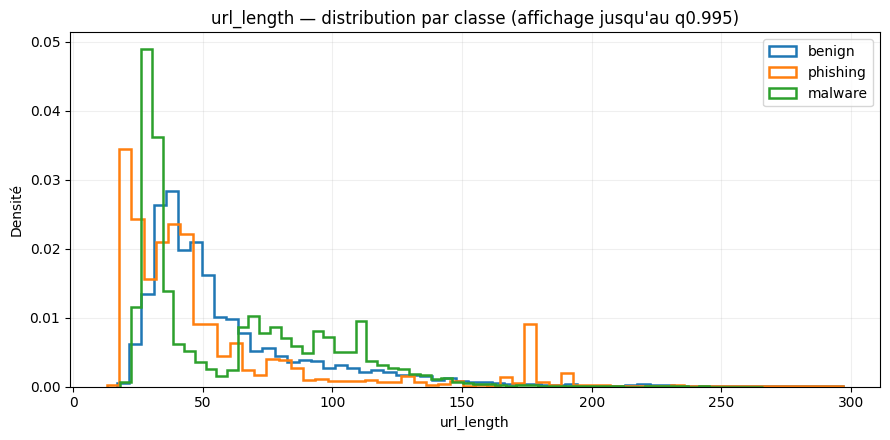

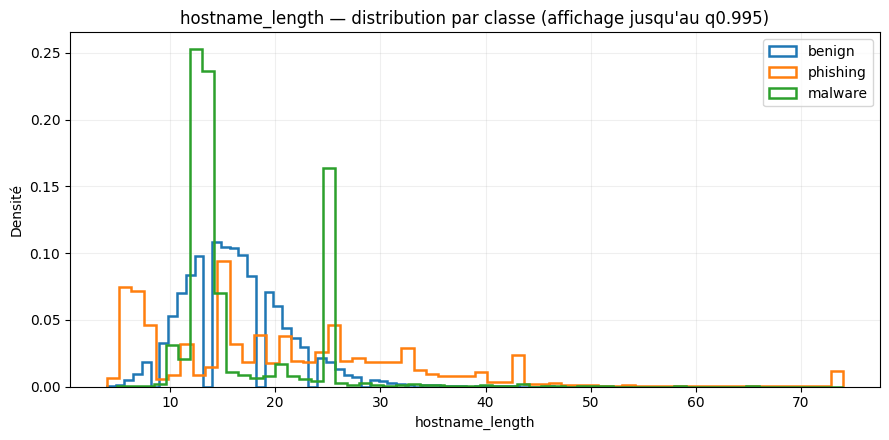

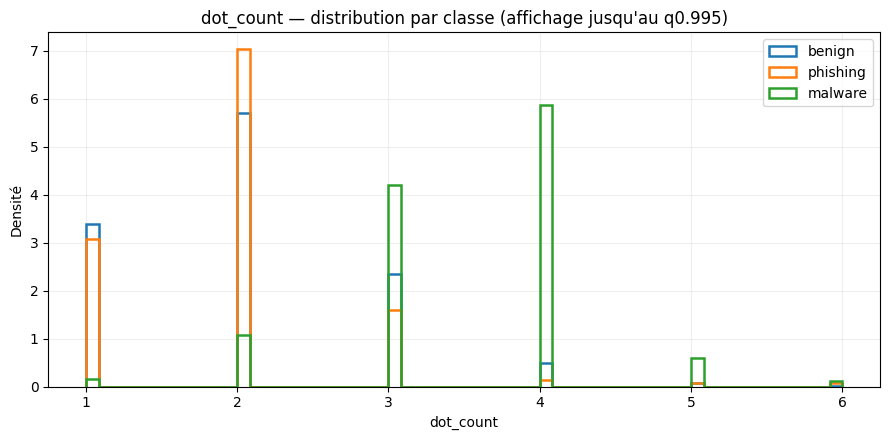

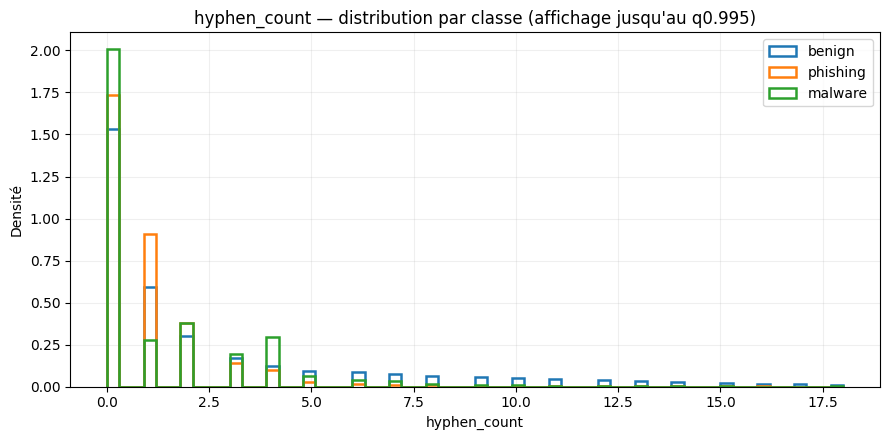

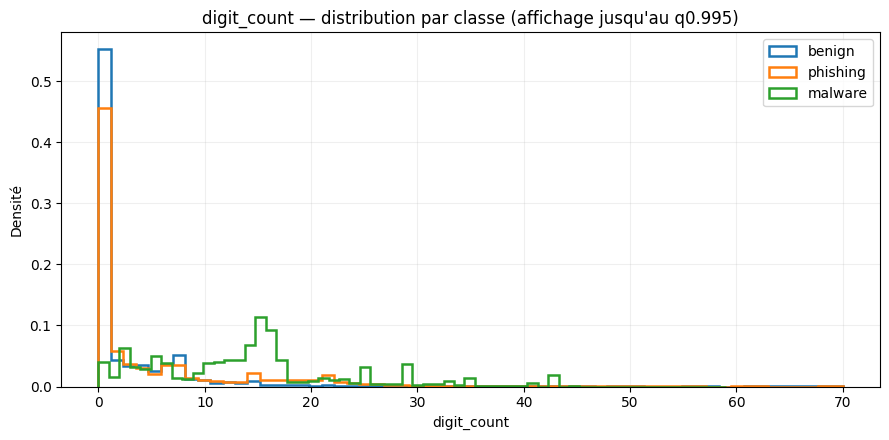

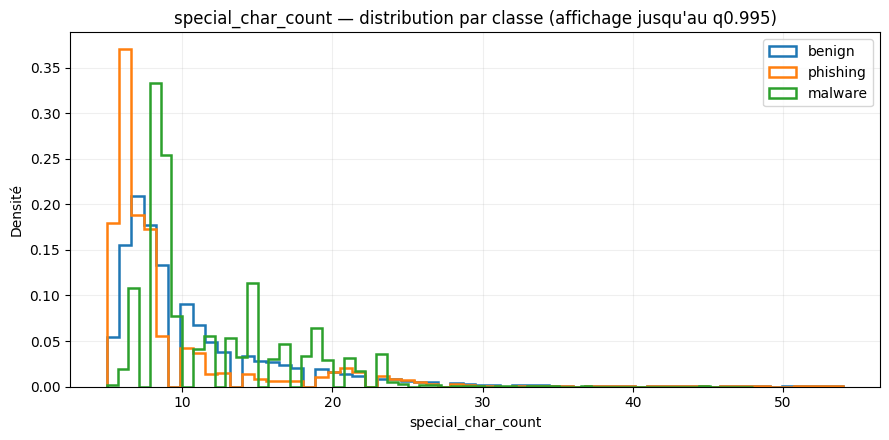

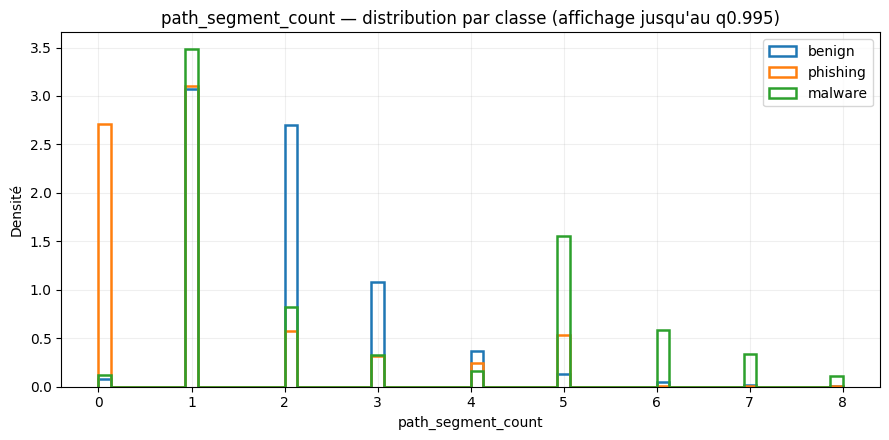

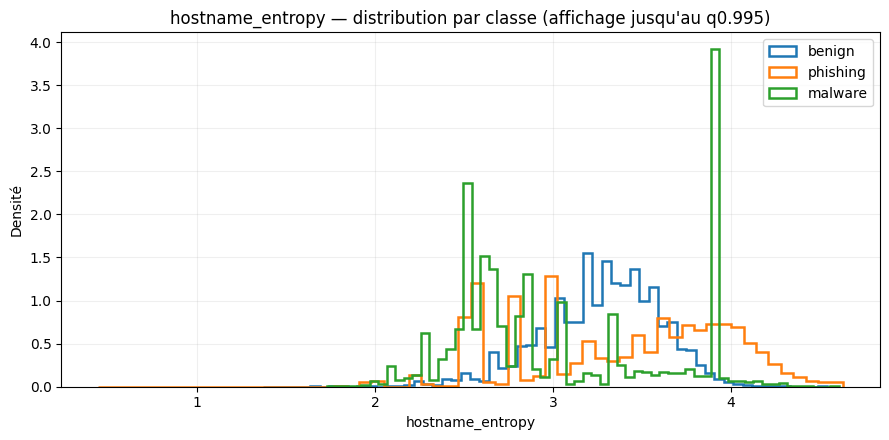

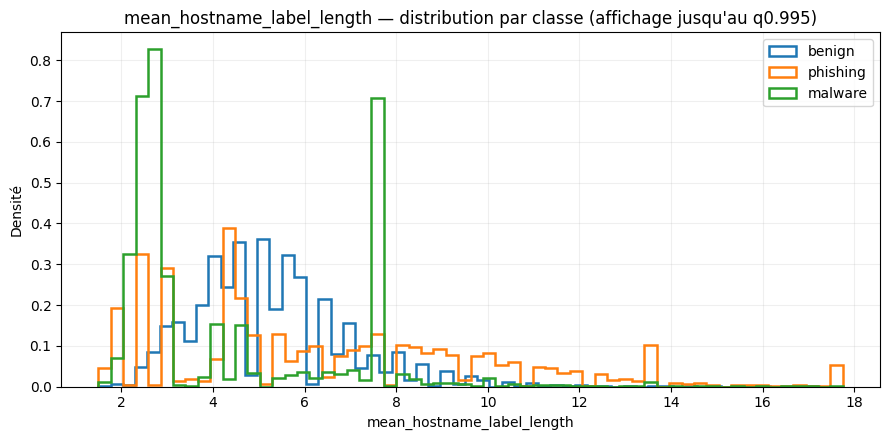

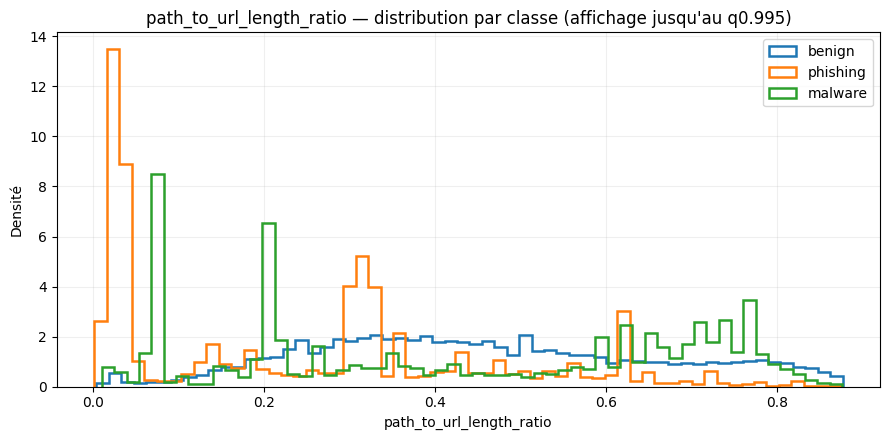

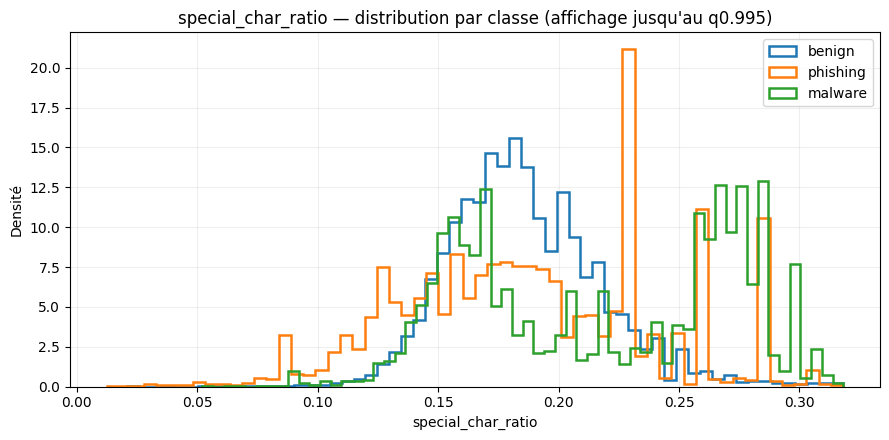

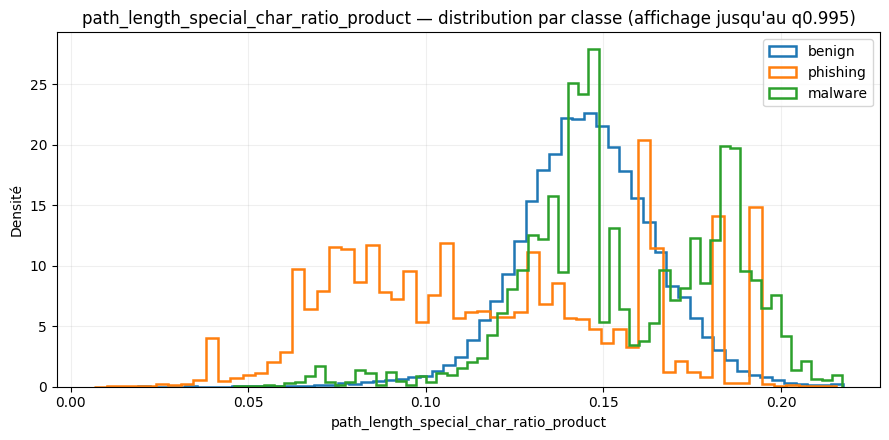

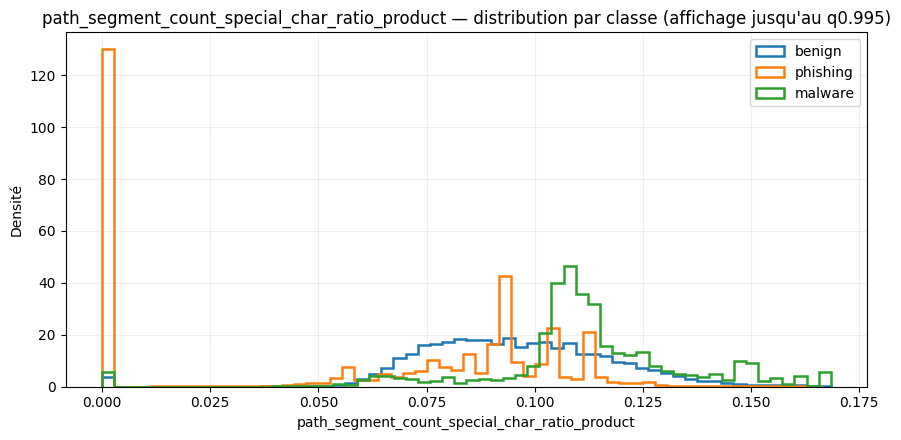

In [17]:
LABEL_ORDER = ["benign", "phishing", "malware"]
VISUAL_QUANTILE = 0.995
HIST_BINS = 60


def plot_feature_distribution_by_class(feature: str) -> None:
    upper = df[feature].quantile(VISUAL_QUANTILE)
    lower = df[feature].min()

    if not np.isfinite(upper) or upper <= lower:
        upper = df[feature].max()

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for label in LABEL_ORDER:
        values = df.loc[df["label_code"] == label, feature]
        visible = values[(values >= lower) & (values <= upper)]

        ax.hist(
            visible,
            bins=HIST_BINS,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=label,
        )

    ax.set_title(
        f"{feature} — distribution par classe "
        f"(affichage jusqu'au q{VISUAL_QUANTILE:.3f})"
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Densité")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


for feature in FEATURE_COLUMNS:
    plot_feature_distribution_by_class(feature)

### Interprétation des distributions par classe

Les graphiques confirment que les 13 features ne possèdent pas toutes le même pouvoir de séparation et qu'aucune variable unique ne sépare parfaitement les trois classes.

Plusieurs tendances visibles sont cohérentes avec les statistiques par classe :

- `digit_count` et `dot_count` distinguent davantage la classe malware ;
- `path_to_url_length_ratio` est sensiblement plus faible pour phishing ;
- `mean_hostname_label_length` et `hostname_entropy` montrent des décalages de distribution entre les classes ;
- `special_char_ratio` est plus élevée pour malware ;
- `path_segment_count` et les deux interactions normalisées présentent également des profils différents selon les classes.

Les distributions se chevauchent toutefois largement.

### Conclusion provisoire

Le problème reste réellement multivarié : le modèle devra combiner plusieurs signaux plutôt que dépendre d'une seule feature.

Ces observations restent exploratoires et ne constituent pas encore une mesure de performance prédictive.

## 9. Corrélations des 13 features

Nous utilisons deux mesures complémentaires :

- **Pearson** : dépendance linéaire ;
- **Spearman** : relation monotone, plus robuste aux formes non linéaires et aux longues queues.

Une forte corrélation n'implique pas qu'une feature doit être supprimée. Elle signale d'abord une redondance potentielle à confronter aux performances de validation des modèles.

In [18]:
pearson_corr = df[FEATURE_COLUMNS].corr(method="pearson")
spearman_corr = df[FEATURE_COLUMNS].corr(method="spearman")

print("=== Pearson ===")
display(pearson_corr.round(3))

print("=== Spearman ===")
display(spearman_corr.round(3))

=== Pearson ===


,url_length,hostname_length,dot_count,hyphen_count,digit_count,special_char_count,path_segment_count,hostname_entropy,mean_hostname_label_length,path_to_url_length_ratio,special_char_ratio,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product
url_length,1.000000,0.127000,0.312000,0.509000,0.692000,0.805000,0.467000,0.115000,0.096000,0.373000,-0.418000,-0.150000,0.122000
hostname_length,0.127000,1.000000,0.224000,0.052000,0.055000,0.008000,-0.159000,0.800000,0.891000,-0.334000,-0.480000,-0.634000,-0.516000
dot_count,0.312000,0.224000,1.000000,0.012000,0.361000,0.293000,0.334000,0.039000,-0.058000,0.090000,-0.008000,0.083000,0.219000
hyphen_count,0.509000,0.052000,0.012000,1.000000,0.198000,0.515000,0.239000,0.100000,0.084000,0.482000,-0.160000,0.046000,0.133000
digit_count,0.692000,0.055000,0.361000,0.198000,1.000000,0.697000,0.239000,-0.084000,-0.029000,0.135000,-0.060000,0.012000,0.136000
special_char_count,0.805000,0.008000,0.293000,0.515000,0.697000,1.000000,0.408000,0.006000,-0.024000,0.384000,-0.075000,0.129000,0.263000
path_segment_count,0.467000,-0.159000,0.334000,0.239000,0.239000,0.408000,1.000000,-0.140000,-0.191000,0.739000,-0.262000,0.224000,0.625000
hostname_entropy,0.115000,0.800000,0.039000,0.100000,-0.084000,0.006000,-0.140000,1.000000,0.834000,-0.248000,-0.529000,-0.638000,-0.538000
mean_hostname_label_length,0.096000,0.891000,-0.058000,0.084000,-0.029000,-0.024000,-0.191000,0.834000,1.000000,-0.299000,-0.538000,-0.670000,-0.567000
path_to_url_length_ratio,0.373000,-0.334000,0.090000,0.482000,0.135000,0.384000,0.739000,-0.248000,-0.299000,1.000000,-0.243000,0.387000,0.641000


=== Spearman ===


,url_length,hostname_length,dot_count,hyphen_count,digit_count,special_char_count,path_segment_count,hostname_entropy,mean_hostname_label_length,path_to_url_length_ratio,special_char_ratio,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product
url_length,1.000000,0.403000,0.371000,0.603000,0.400000,0.857000,0.585000,0.322000,0.334000,0.516000,-0.691000,-0.310000,0.109000
hostname_length,0.403000,1.000000,0.306000,0.212000,0.011000,0.188000,-0.174000,0.863000,0.835000,-0.310000,-0.509000,-0.648000,-0.461000
dot_count,0.371000,0.306000,1.000000,0.023000,0.427000,0.522000,0.265000,0.058000,-0.115000,0.068000,-0.040000,0.056000,0.272000
hyphen_count,0.603000,0.212000,0.023000,1.000000,0.164000,0.641000,0.302000,0.223000,0.254000,0.425000,-0.240000,-0.058000,0.095000
digit_count,0.400000,0.011000,0.427000,0.164000,1.000000,0.488000,0.273000,-0.115000,-0.141000,0.159000,-0.125000,-0.015000,0.218000
special_char_count,0.857000,0.188000,0.522000,0.641000,0.488000,1.000000,0.626000,0.067000,0.028000,0.523000,-0.272000,0.043000,0.402000
path_segment_count,0.585000,-0.174000,0.265000,0.302000,0.273000,0.626000,1.000000,-0.213000,-0.210000,0.824000,-0.268000,0.285000,0.731000
hostname_entropy,0.322000,0.863000,0.058000,0.223000,-0.115000,0.067000,-0.213000,1.000000,0.890000,-0.277000,-0.503000,-0.645000,-0.504000
mean_hostname_label_length,0.334000,0.835000,-0.115000,0.254000,-0.141000,0.028000,-0.210000,0.890000,1.000000,-0.256000,-0.572000,-0.694000,-0.549000
path_to_url_length_ratio,0.516000,-0.310000,0.068000,0.425000,0.159000,0.523000,0.824000,-0.277000,-0.256000,1.000000,-0.237000,0.330000,0.568000


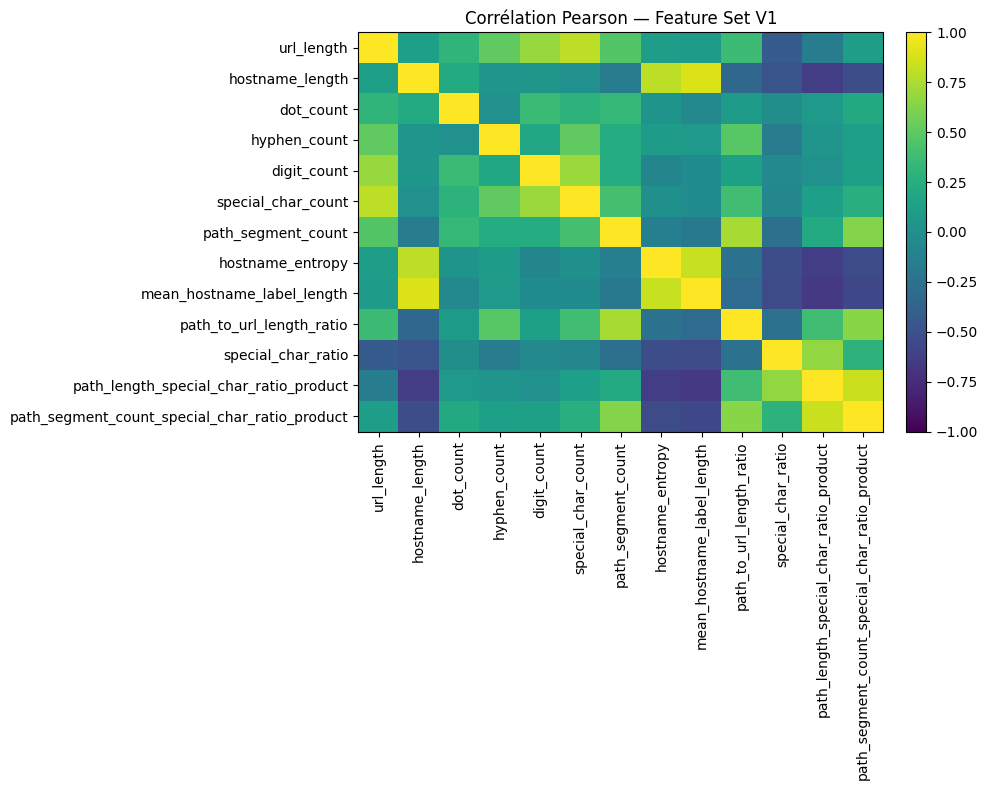

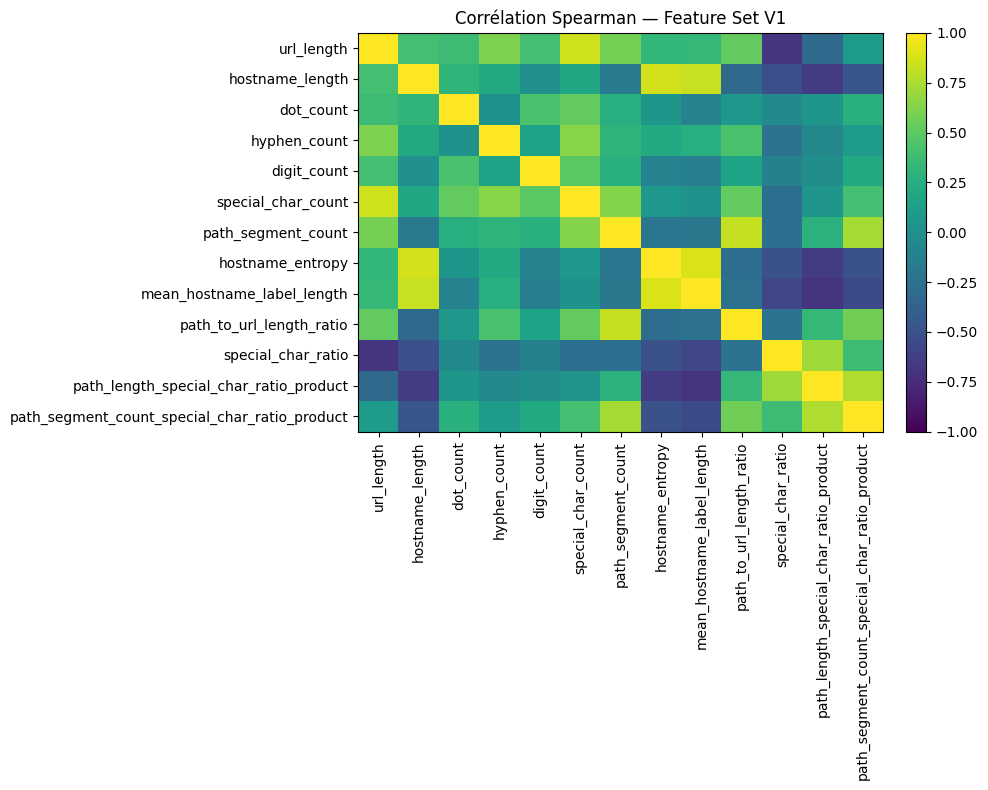

In [19]:
def plot_correlation_matrix(corr: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(corr.to_numpy(), aspect="auto", vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


plot_correlation_matrix(pearson_corr, "Corrélation Pearson — Feature Set V1")
plot_correlation_matrix(spearman_corr, "Corrélation Spearman — Feature Set V1")

### Interprétation des corrélations

Les matrices montrent plusieurs relations fortes entre les features.

Quelques corrélations Pearson importantes sont notamment :

- `hostname_length` ↔ `mean_hostname_label_length` : `0.891` ;
- `hostname_entropy` ↔ `mean_hostname_label_length` : `0.834` ;
- `url_length` ↔ `special_char_count` : `0.805` ;
- les deux features d'interaction : `0.840`.

La matrice de Spearman confirme certaines relations monotones fortes :

- `hostname_entropy` ↔ `mean_hostname_label_length` : `0.890` ;
- `url_length` ↔ `special_char_count` : `0.857` ;
- `path_segment_count` ↔ `path_to_url_length_ratio` : `0.824`.

Pearson et Spearman ne donnent pas toujours la même intensité, ce qui indique que certaines dépendances sont monotones mais pas strictement linéaires.



## 10. Étude des transformations `log1p`

Une longue queue peut gêner certains modèles linéaires. Pour une feature non négative, on peut tester :

\[
x' = \log(1 + x)
\]

`np.log1p` est déterministe et n'apprend aucun paramètre depuis les données. Il peut donc être étudié avant le split sans fuite statistique.

### Ce que nous mesurons

Pour chaque feature suffisamment asymétrique :

1. skewness avant/après ;
2. corrélation Pearson et Spearman avec la feature parente ;
3. corrélation maximale avec les 12 autres features ;
4. **eta carré (`η²`)** comme mesure descriptive de séparation inter-classes.

`η²` représente la fraction de variance de la feature expliquée par la classe. Il ne remplace pas une validation modèle.

> Une transformation n'est **pas appliquée automatiquement** au dataset canonique dans ce notebook. Elle devient une candidate à comparer après le split. Cela évite d'optimiser le préprocessing uniquement sur des graphiques descriptifs.

In [20]:
SKEW_CANDIDATE_THRESHOLD = 1.5
MIN_RELATIVE_SKEW_REDUCTION = 0.25
MAX_RELATIVE_ETA2_DEGRADATION = 0.02


def eta_squared(frame: pd.DataFrame, feature: str, label: str = "label_code") -> float:
    values = frame[[feature, label]].dropna()
    if values.empty:
        return float("nan")

    grand_mean = values[feature].mean()
    ss_total = ((values[feature] - grand_mean) ** 2).sum()

    if ss_total == 0:
        return 0.0

    ss_between = 0.0
    for _, group in values.groupby(label, observed=True):
        ss_between += len(group) * (group[feature].mean() - grand_mean) ** 2

    return float(ss_between / ss_total)


log1p_candidates = [
    feature
    for feature in FEATURE_COLUMNS
    if df[feature].min() >= 0
    and abs(df[feature].skew()) >= SKEW_CANDIDATE_THRESHOLD
]

print("Candidates log1p selon la skewness:")
print(log1p_candidates if log1p_candidates else "Aucune")

Candidates log1p selon la skewness:
['url_length', 'hostname_length', 'dot_count', 'hyphen_count', 'digit_count', 'special_char_count', 'path_segment_count']


In [21]:
transformation_rows = []
transformed_series_by_feature = {}

for feature in log1p_candidates:
    parent = df[feature]
    transformed = np.log1p(parent)
    transformed_series_by_feature[feature] = transformed

    other_features = [name for name in FEATURE_COLUMNS if name != feature]
    comparison = df[other_features].copy()
    comparison["__transformed__"] = transformed

    pearson_other = (
        comparison.corr(method="pearson")["__transformed__"]
        .drop("__transformed__")
        .abs()
        .sort_values(ascending=False)
    )
    spearman_other = (
        comparison.corr(method="spearman")["__transformed__"]
        .drop("__transformed__")
        .abs()
        .sort_values(ascending=False)
    )

    temp = df[["label_code"]].copy()
    temp["before"] = parent
    temp["after"] = transformed

    skew_before = float(parent.skew())
    skew_after = float(transformed.skew())
    abs_before = abs(skew_before)
    abs_after = abs(skew_after)
    relative_skew_reduction = (
        (abs_before - abs_after) / abs_before
        if abs_before > 0
        else 0.0
    )

    eta_before = eta_squared(temp.rename(columns={"before": feature}), feature)
    eta_after = eta_squared(temp.rename(columns={"after": feature}), feature)

    eta_ratio = (
        eta_after / eta_before
        if eta_before > 0
        else 1.0
    )

    transformation_rows.append(
        {
            "feature": feature,
            "skew_before": skew_before,
            "skew_after": skew_after,
            "relative_skew_reduction": relative_skew_reduction,
            "eta2_before": eta_before,
            "eta2_after": eta_after,
            "eta2_ratio_after_before": eta_ratio,
            "pearson_parent": parent.corr(transformed, method="pearson"),
            "spearman_parent": parent.corr(transformed, method="spearman"),
            "max_abs_pearson_other": pearson_other.iloc[0] if not pearson_other.empty else np.nan,
            "most_correlated_pearson_other": pearson_other.index[0] if not pearson_other.empty else None,
            "max_abs_spearman_other": spearman_other.iloc[0] if not spearman_other.empty else np.nan,
            "most_correlated_spearman_other": spearman_other.index[0] if not spearman_other.empty else None,
            "candidate_for_model_comparison": bool(
                relative_skew_reduction >= MIN_RELATIVE_SKEW_REDUCTION
                and eta_ratio >= (1 - MAX_RELATIVE_ETA2_DEGRADATION)
            ),
        }
    )

transformation_report = pd.DataFrame(transformation_rows)

if transformation_report.empty:
    print("Aucune transformation log1p candidate selon le seuil actuel.")
else:
    display(
        transformation_report
        .set_index("feature")
        .sort_values("relative_skew_reduction", ascending=False)
    )

,skew_before,skew_after,relative_skew_reduction,eta2_before,eta2_after,eta2_ratio_after_before,pearson_parent,spearman_parent,max_abs_pearson_other,most_correlated_pearson_other,max_abs_spearman_other,most_correlated_spearman_other,candidate_for_model_comparison
feature,,,,,,,,,,,,,
digit_count,10.681997,0.436360,0.959150,0.086459,0.238548,2.759091,0.730229,1.000000,0.453784,url_length,0.487863,special_char_count,True
dot_count,3.693743,0.216870,0.941287,0.289926,0.295550,1.019399,0.957866,1.000000,0.328727,digit_count,0.522332,special_char_count,True
hostname_length,2.135154,0.143856,0.932625,0.053820,0.012660,0.235237,0.936567,1.000000,0.843302,hostname_entropy,0.862523,hostname_entropy,False
special_char_count,15.899056,1.405376,0.911606,0.022195,0.080261,3.616132,0.812831,1.000000,0.792174,url_length,0.856839,url_length,True
url_length,9.159135,0.863677,0.905703,0.001605,0.025403,15.828590,0.843430,1.000000,0.684653,special_char_count,0.856839,special_char_count,True
path_segment_count,1.699278,0.204925,0.879405,0.146860,0.189886,1.292974,0.940296,1.000000,0.814410,path_to_url_length_ratio,0.824084,path_to_url_length_ratio,True
hyphen_count,6.329895,1.127003,0.821955,0.060579,0.042299,0.698250,0.871807,1.000000,0.513451,path_to_url_length_ratio,0.640884,special_char_count,False


### Résumé de l'étude `log1p`

Sept features ont été détectées comme suffisamment asymétriques pour tester `log1p` :

- `url_length` ;
- `hostname_length` ;
- `dot_count` ;
- `hyphen_count` ;
- `digit_count` ;
- `special_char_count` ;
- `path_segment_count`.

La transformation réduit fortement la skewness pour toutes ces variables.

Les diminutions les plus nettes incluent notamment :

- `digit_count` : `10.68` → `0.44` ;
- `dot_count` : `3.69` → `0.22` ;
- `special_char_count` : `15.90` → `1.41` ;
- `url_length` : `9.16` → `0.86` ;
- `path_segment_count` : `1.70` → `0.20`.

La métrique exploratoire `η²` augmente pour `digit_count`, `dot_count`, `special_char_count`, `url_length` et `path_segment_count`. Ces cinq variables satisfont donc la règle heuristique actuelle et deviennent des candidates à une comparaison de modèle.

À l'inverse, `hostname_length` et `hyphen_count` voient leur `η²` diminuer après transformation et ne sont pas retenues par cette règle.

La corrélation Spearman entre chaque feature et sa transformation vaut `1`, ce qui est attendu puisque `log1p` est monotone.

### Décision

Aucune feature n'est remplacée définitivement dans ce notebook.

Les cinq transformations candidates devront être revalidées sur le futur ensemble d'entraînement avant d'être intégrées à un pipeline final.

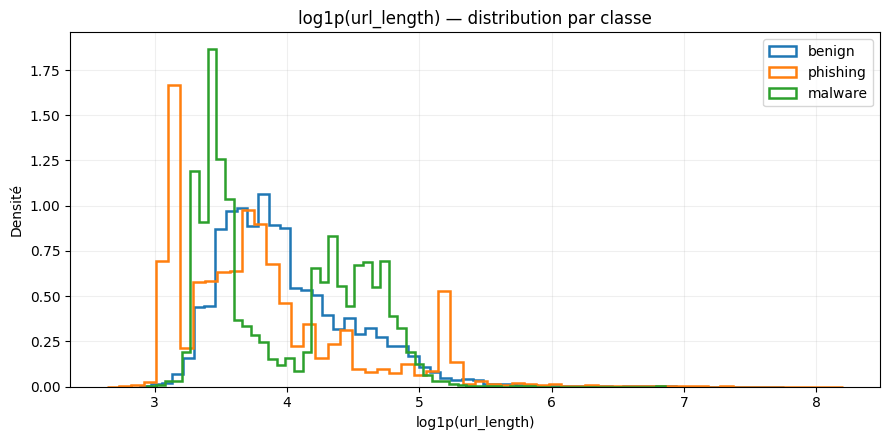

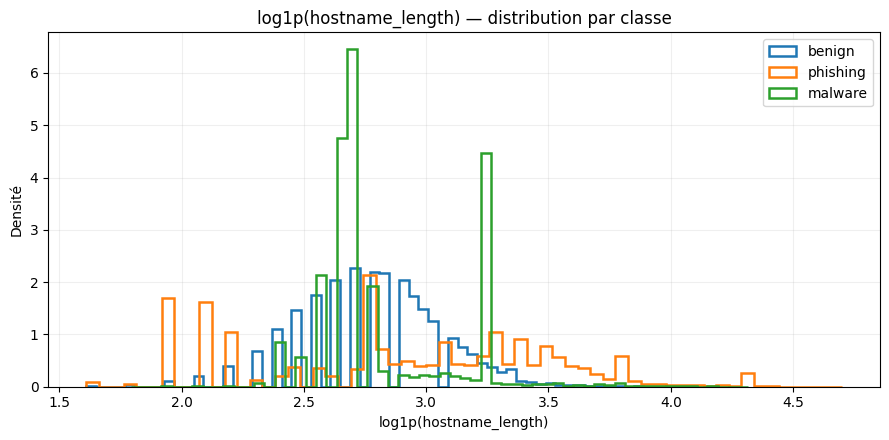

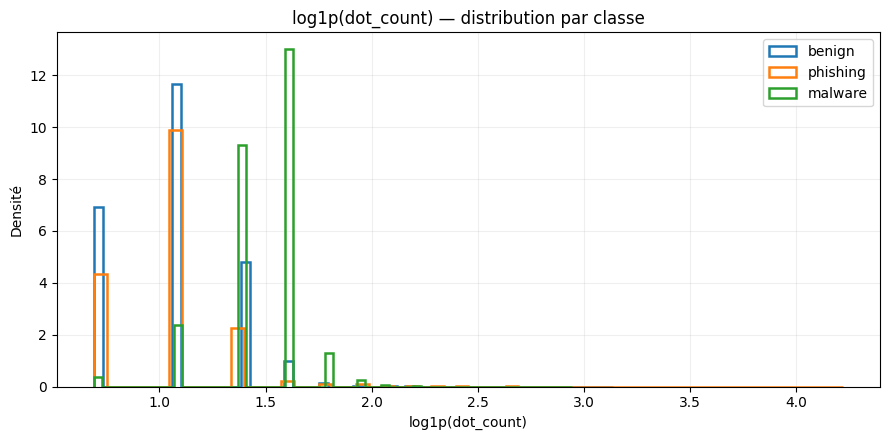

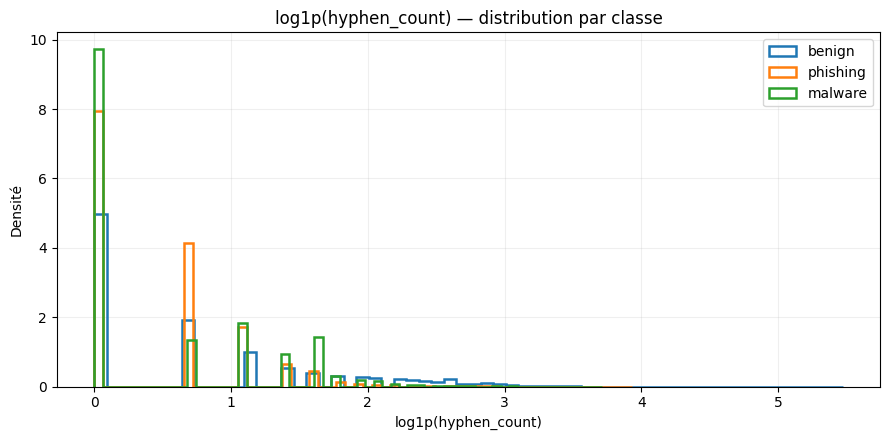

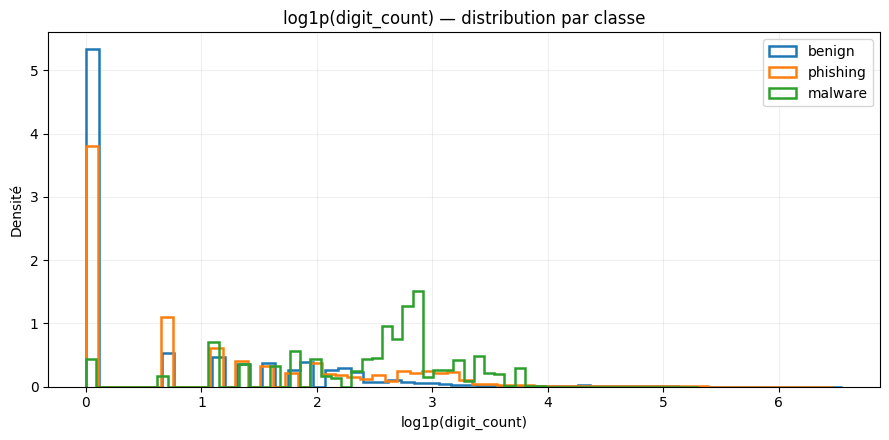

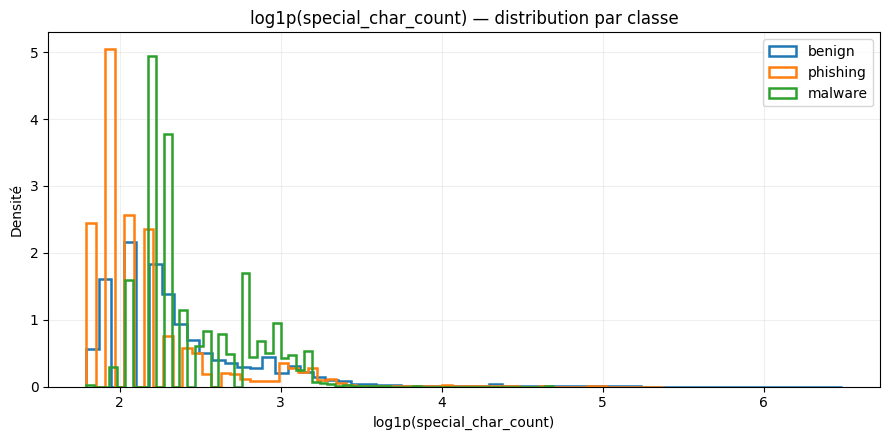

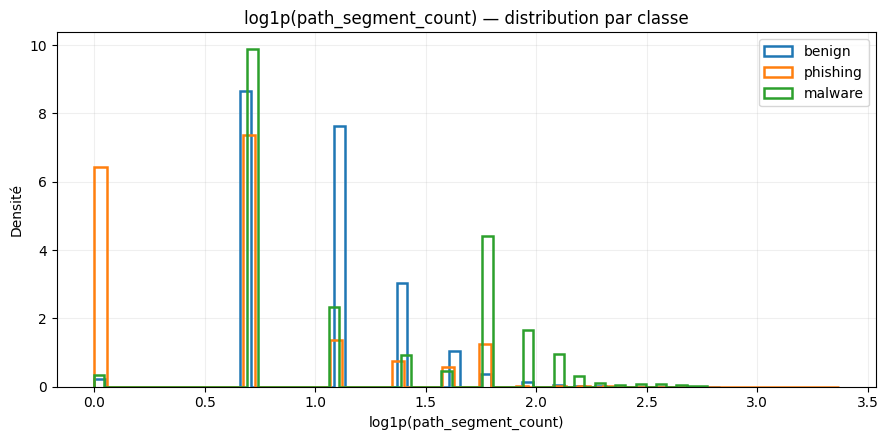

In [22]:
def plot_log1p_candidate(feature: str) -> None:
    transformed = np.log1p(df[feature])
    transformed_name = f"log1p({feature})"

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for label in LABEL_ORDER:
        values = transformed[df["label_code"] == label]
        ax.hist(
            values,
            bins=HIST_BINS,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=label,
        )

    ax.set_title(f"{transformed_name} — distribution par classe")
    ax.set_xlabel(transformed_name)
    ax.set_ylabel("Densité")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


for feature in log1p_candidates:
    plot_log1p_candidate(feature)

### Interprétation visuelle des transformations candidates

Les graphiques avant/après servent ici à vérifier visuellement l'effet de `log1p` sur les longues queues observées.

Ils confirment que la transformation compresse fortement les valeurs extrêmes des variables candidates sans changer leur ordre relatif.

Cette amélioration de forme ne suffit toutefois pas à justifier seule une transformation : la décision finale sera prise sur la performance de validation des modèles, après le split.

### Règle de décision proposée

La colonne `candidate_for_model_comparison` signifie uniquement :

- `log1p` réduit nettement l'asymétrie ;
- la séparation descriptive inter-classes (`η²`) ne se dégrade pas fortement.

La transformation définitive devra être choisie **après le split**, en comparant les performances de validation du pipeline avec et sans transformation.

Nous ne conservons pas simultanément une feature parente et sa transformation par défaut, afin de limiter la redondance et de garder une architecture ML simple.

## 10 bis. Résolution des `group_key` multi-labels

Le contrôle précédent a détecté au moins un `group_key` associé à plusieurs labels.

### Pourquoi ce cas doit être traité ?

Dans ce projet, `group_key` représente :

- le domaine enregistrable déterminé via la Public Suffix List ;
- ou l'adresse IP normalisée lorsque le hostname est une IP.

Il s'agit donc d'une **identité de groupe**, et non d'une URL exacte.

Un même domaine peut légitimement héberger plusieurs URL avec des comportements différents.
Par exemple, un domaine compromis peut contenir à la fois des ressources normales et des URL malveillantes.

Nous ne devons donc **pas relabelliser automatiquement** ces observations.

### Politique retenue pour le baseline V1

Pour obtenir un premier benchmark simple et particulièrement strict :

1. identifier les groupes associés à plusieurs labels ;
2. mesurer leur poids dans le dataset ;
3. ne jamais afficher leurs valeurs de `group_key` ;
4. exclure temporairement **l'intégralité de ces groupes** du dataset destiné au split ;
5. conserver le DataFrame original intact pour audit et traçabilité ;
6. vérifier qu'après cette quarantaine chaque `group_key` ne possède plus qu'un seul label.

Cette exclusion est une décision de préparation du dataset, pas un nettoyage destructif de la base.

Les groupes retirés pourront ultérieurement constituer un **jeu d'évaluation difficile** intéressant, car ils représentent des domaines dont le comportement est ambigu ou mixte.

> Aucune ligne n'est supprimée de PostgreSQL et aucun label n'est modifié.

In [23]:
# diagnostiquer sans exposer les domaines
group_label_profile = (
    df.groupby("group_key", observed=True)
    .agg(
        label_count=("label_code", "nunique"),
        sample_count=("sample_id", "size"),
    )
)

shared_group_keys = group_label_profile.index[
    group_label_profile["label_count"] > 1
]

shared_group_mask = df["group_key"].isin(
    shared_group_keys
)

shared_group_rows = df.loc[
    shared_group_mask
].copy()

shared_group_count = len(
    shared_group_keys
)

shared_group_sample_count = int(
    shared_group_mask.sum()
)

shared_group_sample_pct = (
    100
    * shared_group_sample_count
    / len(df)
)

print(
    f"Groupes multi-labels : {shared_group_count:,}"
)

print(
    "Observations appartenant à ces groupes : "
    f"{shared_group_sample_count:,}"
)

print(
    "Part du dataset concernée : "
    f"{shared_group_sample_pct:.4f}%"
)

Groupes multi-labels : 168
Observations appartenant à ces groupes : 12,126
Part du dataset concernée : 7.7822%


### Interprétation du conflit détecté

L'audit identifie :

- `168` groupes associés à plusieurs labels ;
- `12 126` observations appartenant à ces groupes ;
- soit `7.7822 %` du pool initial.

Le phénomène n'est donc pas limité à quelques lignes isolées.

Comme `group_key` représente un domaine enregistrable ou une IP, un groupe multi-label peut correspondre à plusieurs URL différentes partageant la même infrastructure. Il ne faut donc ni relabelliser automatiquement ces observations, ni résoudre le problème par simple déduplication.

### Nature des conflits

Avant d'exclure ces groupes du dataset destiné au split, nous regardons **quelles combinaisons de labels** sont concernées.

Les valeurs des `group_key` ne sont volontairement pas affichées afin d'éviter l'exposition inutile de domaines ou d'IOC.

Cette analyse permet notamment de distinguer :

- `benign + phishing` ;
- `benign + malware` ;
- `phishing + malware` ;
- ou éventuellement les trois classes.

Nous mesurons également le nombre d'observations retirées par classe afin de vérifier que la quarantaine ne crée pas un déséquilibre important.

In [24]:
shared_group_label_signatures = (
    shared_group_rows
    .groupby(
        "group_key",
        observed=True,
    )["label_code"]
    .agg(
        lambda labels: " + ".join(
            sorted(
                set(labels)
            )
        )
    )
)

shared_group_signature_summary = (
    shared_group_label_signatures
    .value_counts()
    .rename_axis(
        "label_combination"
    )
    .rename(
        "group_count"
    )
    .to_frame()
)

display(
    shared_group_signature_summary
)

,group_count
label_combination,
benign + phishing,126
malware + phishing,25
benign + malware,11
benign + malware + phishing,6


### Résumé des combinaisons de labels conflictuelles

Les `168` groupes multi-labels se répartissent ainsi :

- benign + phishing : `126` groupes ;
- malware + phishing : `25` groupes ;
- benign + malware : `11` groupes ;
- benign + malware + phishing : `6` groupes.

Les conflits impliquent donc les trois classes et ne peuvent pas être résolus proprement par une règle de priorité entre labels.

La quarantaine complète de ces groupes reste la stratégie la plus conservatrice pour le premier baseline.

In [25]:
# impact par classe
class_counts_before_quarantine = (
    df["label_code"]
    .value_counts()
    .sort_index()
)

quarantined_class_counts = (
    shared_group_rows[
        "label_code"
    ]
    .value_counts()
    .reindex(
        class_counts_before_quarantine.index,
        fill_value=0,
    )
)

class_counts_after_quarantine = (
    class_counts_before_quarantine
    - quarantined_class_counts
)

quarantine_impact = pd.DataFrame(
    {
        "before": (
            class_counts_before_quarantine
        ),
        "quarantined": (
            quarantined_class_counts
        ),
        "after": (
            class_counts_after_quarantine
        ),
    }
)

quarantine_impact[
    "quarantined_pct"
] = (
    100
    * quarantine_impact["quarantined"]
    / quarantine_impact["before"]
)

display(
    quarantine_impact
)

,before,quarantined,after,quarantined_pct
label_code,,,,
benign,58668,235,58433,0.400559
malware,29925,1334,28591,4.457811
phishing,67225,10557,56668,15.703979


### Impact de la quarantaine sur les classes

L'exclusion des groupes multi-labels n'affecte pas les trois classes de manière uniforme.

Observations retirées :

- benign : `235`, soit `0.40 %` de la classe ;
- malware : `1 334`, soit `4.46 %` ;
- phishing : `10 557`, soit `15.70 %`.

Après quarantaine, il reste :

- benign : `58 433` ;
- malware : `28 591` ;
- phishing : `56 668`.

Le dataset admissible au split contient donc `143 692` observations.

### Point méthodologique important

La quarantaine résout proprement le problème des groupes multi-labels pour le baseline, mais son impact est asymétrique et non négligeable, particulièrement sur phishing.

Elle peut donc introduire un biais de sélection : les URL phishing appartenant à des domaines au comportement mixte sont sous-représentées dans le dataset d'entraînement.

Pour cette raison :

1. le pool original `df` doit être conservé intact ;
2. la quarantaine doit rester une décision explicitement documentée ;
3. les groupes quarantainés ne doivent pas être détruits ;
4. ils pourront ultérieurement servir de jeu de robustesse « domaine mixte ».

Le baseline peut continuer sur `split_df`, mais les performances obtenues devront être interprétées comme celles d'un dataset composé uniquement de groupes mono-labels.

### Construction du dataset admissible au split

Le DataFrame `df` reste le reflet intégral du snapshot ML.

Nous créons maintenant un second DataFrame :

`df_split_ready`

Il contient uniquement les observations appartenant à des groupes mono-labels.

Cette séparation est volontaire :

- `df` = pool ML complet, utile pour audit et traçabilité ;
- `shared_group_rows` = observations mises en quarantaine ;
- `df_split_ready` = population candidate pour le futur split.

Aucune modification n'est persistée en base.

In [26]:
df_split_ready = (
    df.loc[
        ~shared_group_mask
    ]
    .copy()
    .reset_index(drop=True)
)

# Dataset de référence pour tous les audits
# et le futur split.
split_df = df_split_ready

print(
    "Dataset complet : "
    f"{len(df):,}"
)

print(
    "Quarantaine multi-label : "
    f"{len(shared_group_rows):,}"
)

print(
    "Dataset admissible au split : "
    f"{len(split_df):,}"
)

Dataset complet : 155,818
Quarantaine multi-label : 12,126
Dataset admissible au split : 143,692


In [27]:
# Contrôles bloquants post-quarantaine.
remaining_group_label_counts = (
    split_df
    .groupby(
        "group_key",
        observed=True,
    )["label_code"]
    .nunique()
)

remaining_shared_groups = int(
    (
        remaining_group_label_counts
        > 1
    ).sum()
)

remaining_labels = set(
    split_df[
        "label_code"
    ]
    .dropna()
    .unique()
)

if remaining_shared_groups != 0:
    raise RuntimeError(
        "La quarantaine des groupes "
        "multi-labels a échoué."
    )

if remaining_labels != EXPECTED_LABELS:
    raise RuntimeError(
        "La quarantaine a supprimé "
        "au moins une classe complète : "
        f"{sorted(remaining_labels)}"
    )

if split_df[
    "sample_id"
].duplicated().any():
    raise RuntimeError(
        "Un sample_id est dupliqué "
        "après la quarantaine."
    )

print(
    "✓ Aucun group_key multi-label "
    "dans split_df."
)

print(
    "✓ Les trois classes sont présentes."
)

print(
    "✓ Aucun sample_id dupliqué."
)

print(
    "✓ Dataset admissible "
    "au futur split."
)

✓ Aucun group_key multi-label dans split_df.
✓ Les trois classes sont présentes.
✓ Aucun sample_id dupliqué.
✓ Dataset admissible au futur split.


### Validation du dataset après quarantaine

Les contrôles bloquants passent tous :

- aucun `group_key` multi-label ne subsiste ;
- les trois classes sont toujours présentes ;
- aucun `sample_id` n'est dupliqué ;
- le dataset est structurellement admissible à un split group-aware.

À partir de cette cellule, `split_df` devient la population de référence pour tous les audits directement liés au futur train/validation/test.

Le DataFrame original `df` reste uniquement la représentation complète et traçable du pool avant quarantaine.

## 11. Audit `group_key` avant split

`group_key` est une métadonnée de split, jamais une feature du modèle.

Le même groupe ne devra jamais apparaître dans plusieurs ensembles. Nous vérifions donc :

- groupes partagés entre plusieurs labels ;
- taille des groupes ;
- groupes dominants susceptibles de rendre les ratios 80/10/10 approximatifs ;
- concentration des groupes par classe.

Pour limiter l'exposition d'IOC/domaines, les valeurs de `group_key` ne sont pas imprimées : seules des agrégations sont affichées.

In [28]:
group_label_counts = (
    split_df
    .groupby(
        "group_key",
        observed=True,
    )["label_code"]
    .nunique()
)

shared_label_groups = int(
    (
        group_label_counts
        > 1
    ).sum()
)

group_sizes = (
    split_df
    .groupby(
        [
            "label_code",
            "group_key",
        ],
        observed=True,
    )
    .size()
    .rename(
        "group_size"
    )
    .reset_index()
)

group_size_summary = (
    group_sizes
    .groupby(
        "label_code",
        observed=True,
    )["group_size"]
    .describe(
        percentiles=[
            0.5,
            0.75,
            0.9,
            0.95,
            0.99,
        ]
    )
)

largest_group_summary = (
    group_sizes
    .groupby(
        "label_code",
        observed=True,
    )["group_size"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "max",
        ]
    )
)

class_totals = (
    split_df
    .groupby(
        "label_code",
        observed=True,
    )
    .size()
)

largest_group_summary[
    "largest_group_pct_of_class"
] = [
    (
        100
        * largest_group_summary.loc[
            label,
            "max",
        ]
        / class_totals.loc[label]
    )
    for label
    in largest_group_summary.index
]

print(
    "Groupes partagés entre labels : "
    f"{shared_label_groups}"
)

display(
    group_size_summary
)

display(
    largest_group_summary
)

if shared_label_groups > 0:
    raise RuntimeError(
        "Un group_key multi-label "
        "subsiste après quarantaine."
    )

Groupes partagés entre labels : 0


,count,mean,std,min,50%,75%,90%,95%,99%,max
label_code,,,,,,,,,,
benign,"53,272.000000",1.096880,0.513544,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,60.000000
malware,"7,090.000000",4.032581,71.831433,1.000000,2.000000,2.000000,3.000000,7.000000,21.000000,"5,489.000000"
phishing,"24,803.000000",2.284724,51.584835,1.000000,1.000000,1.000000,2.000000,2.000000,7.000000,"4,584.000000"


,count,mean,median,max,largest_group_pct_of_class
label_code,,,,,
benign,53272,1.096880,1.000000,60,0.102682
malware,7090,4.032581,2.000000,5489,19.198349
phishing,24803,2.284724,1.000000,4584,8.089221


### Interprétation de la structure des groupes après quarantaine

Après exclusion des `168` groupes multi-labels, aucun groupe n'est partagé entre plusieurs classes.

Le dataset contient désormais `85 165` groupes mono-labels.

La taille des groupes est cependant très différente selon les classes.

#### Benign

- `53 272` groupes ;
- taille médiane : `1` ;
- groupe maximum : `60` observations ;
- le plus grand groupe représente environ `0.10 %` de la classe.

#### Phishing

- `24 803` groupes ;
- taille médiane : `1` ;
- groupe maximum : `4 584` observations ;
- ce groupe représente environ `8.09 %` de la classe phishing.

#### Malware

- `7 090` groupes ;
- taille médiane : `2` ;
- groupe maximum : `5 489` observations ;
- ce groupe représente environ `19.20 %` de la classe malware.

### Conséquence pour le split

La présence de groupes très volumineux, particulièrement pour malware, signifie qu'un ratio exact comme `80/10/10` ne pourra pas nécessairement être atteint tout en conservant les groupes intacts.

La priorité du futur splitter devra donc être :

1. aucune contamination de `group_key` entre les splits ;
2. conservation raisonnable des proportions de classes ;
3. approximation des ratios globaux.

Les ratios obtenus devront être mesurés et affichés après le split plutôt que supposés exacts.

## 12. Audit temporel de PhishTank et URLhaus

Avant de décider un split temporel, nous devons connaître la distribution réelle des dates.

Nous analysons séparément :

- plage min/max ;
- quantiles temporels ;
- nombre d'échantillons par année ;
- pourcentage annuel et pourcentage cumulé ;
- éventuels trous ou concentrations ;
- durée temporelle couverte par un même `group_key`.

### Important

Les bornes train/validation/test **ne sont pas codées arbitrairement** dans ce notebook. Elles seront décidées après lecture de ces résultats.

Pour les données benign issues de HTTP Archive, cette étude temporelle n'est pas utilisée pour imposer un historique comparable aux deux sources de menace.

### Population utilisée pour l'audit temporel

À partir de cette section, les statistiques temporelles sont calculées uniquement sur `split_df`, c'est-à-dire après quarantaine des groupes multi-labels.

Les anciennes statistiques temporelles calculées sur le pool complet ne doivent plus servir à déterminer les frontières du split.

Nous analysons ici la distribution temporelle de la population réellement admissible au futur entraînement.

In [29]:
split_df["first_observed_at"] = pd.to_datetime(
    split_df["first_observed_at"],
    utc=True,
    errors="coerce",
)

split_df["last_observed_at"] = pd.to_datetime(
    split_df["last_observed_at"],
    utc=True,
    errors="coerce",
)

threat_df = (
    split_df.loc[
        split_df["source"].isin(
            THREAT_SOURCES
        )
    ]
    .copy()
)

missing_threat_dates = (
    threat_df
    .groupby(
        "source",
        observed=True,
    )["first_observed_at"]
    .apply(
        lambda series: int(
            series.isna().sum()
        )
    )
    .rename(
        "missing_first_observed_at"
    )
)

display(
    missing_threat_dates.to_frame()
)

if missing_threat_dates.sum() > 0:
    raise RuntimeError(
        "Date métier manquante pour "
        "URLhaus/PhishTank. "
        "Un split temporel ne serait "
        "pas fiable."
    )

,missing_first_observed_at
source,
phishtank,0
urlhaus,0


### Interprétation — disponibilité des dates métier

Après quarantaine, aucune date `first_observed_at` n'est manquante :

- PhishTank : `0` date manquante ;
- URLhaus : `0` date manquante.

La dimension temporelle est donc exploitable pour les deux sources de menace.

Cela ne signifie pas encore qu'un split temporel est le meilleur choix pour le baseline : il faut d'abord examiner la couverture réelle des périodes.

In [30]:
def datetime_quantiles(series: pd.Series) -> pd.Series:
    clean = series.dropna().sort_values()
    return pd.Series(
        {
            "min": clean.min(),
            "q10": clean.quantile(0.10),
            "q25": clean.quantile(0.25),
            "median": clean.quantile(0.50),
            "q75": clean.quantile(0.75),
            "q90": clean.quantile(0.90),
            "max": clean.max(),
        }
    )


temporal_quantiles = (
    threat_df.groupby("source", observed=True)["first_observed_at"]
    .apply(datetime_quantiles)
    .unstack()
)

display(temporal_quantiles)

,min,q10,q25,median,q75,q90,max
source,,,,,,,
phishtank,2011-02-18 10:50:32+00:00,2023-12-05 03:55:41.400000+00:00,2024-09-03 08:51:23+00:00,2026-01-24 11:03:56.500000+00:00,2026-05-25 06:46:26.500000+00:00,2026-07-06 08:45:10.500000+00:00,2026-07-31 12:53:07+00:00
urlhaus,2018-06-05 22:09:14+00:00,2025-06-18 00:26:26+00:00,2025-11-15 16:31:44.500000+00:00,2026-07-10 23:16:10+00:00,2026-07-26 12:19:41+00:00,2026-08-03 10:17:15+00:00,2026-08-10 13:51:21+00:00


### Interprétation — quantiles temporels

Les deux sources possèdent des historiques très différents.

#### PhishTank

La plage théorique s'étend du `2011-02-18` au `2026-07-31`, mais les quantiles montrent que l'essentiel du volume est beaucoup plus récent :

- q10 : `2023-12-05` ;
- q25 : `2024-09-03` ;
- médiane : `2026-01-24` ;
- q75 : `2026-05-25` ;
- q90 : `2026-07-06`.

La longue histoire remontant à 2011 correspond donc à une faible partie de la population.

#### URLhaus

La plage s'étend du `2018-06-05` au `2026-08-10`, avec une concentration temporelle encore plus forte :

- q10 : `2025-06-18` ;
- q25 : `2025-11-15` ;
- médiane : `2026-07-10` ;
- q75 : `2026-07-26` ;
- q90 : `2026-08-03`.

La moitié des observations URLhaus se situe donc après le `2026-07-10`.

### Conséquence

Une frontière calendaire identique pour PhishTank et URLhaus ne produirait pas des volumes comparables entre les classes.

Un split temporel reste pertinent comme **test de robustesse future**, mais il serait trop contraignant et fortement dépendant des sources pour constituer notre premier benchmark.

In [31]:
threat_df["observation_year"] = threat_df["first_observed_at"].dt.year

yearly_counts = (
    threat_df.groupby(["source", "observation_year"], observed=True)
    .size()
    .rename("count")
    .reset_index()
)

yearly_counts["source_total"] = yearly_counts.groupby("source", observed=True)["count"].transform("sum")
yearly_counts["percentage"] = 100 * yearly_counts["count"] / yearly_counts["source_total"]
yearly_counts["cumulative_percentage"] = yearly_counts.groupby("source", observed=True)["percentage"].cumsum()

print("=== Distribution annuelle détaillée ===")
display(yearly_counts)

=== Distribution annuelle détaillée ===


,source,observation_year,count,source_total,percentage,cumulative_percentage
0,phishtank,2011,1,56668,0.001765,0.001765
1,phishtank,2012,1,56668,0.001765,0.003529
2,phishtank,2013,2,56668,0.003529,0.007059
3,phishtank,2016,2,56668,0.003529,0.010588
4,phishtank,2017,9,56668,0.015882,0.026470
5,phishtank,2018,17,56668,0.029999,0.056469
6,phishtank,2019,6,56668,0.010588,0.067057
7,phishtank,2020,25,56668,0.044117,0.111174
8,phishtank,2021,80,56668,0.141173,0.252347
9,phishtank,2022,820,56668,1.447025,1.699372


### Interprétation — distribution annuelle

La table annuelle confirme la forte concentration des menaces sur les périodes récentes.

#### PhishTank

- 2023 : `5 054` observations (`8.92 %`) ;
- 2024 : `13 243` (`23.37 %`) ;
- 2025 : `8 331` (`14.70 %`) ;
- 2026 : `29 077` (`51.31 %`).

À la fin de 2022, seulement `1.70 %` environ de la population PhishTank post-quarantaine est cumulée. Autrement dit, plus de `98 %` des observations se situent à partir de 2023.

#### URLhaus

- 2024 : `961` observations (`3.36 %`) ;
- 2025 : `6 212` (`21.73 %`) ;
- 2026 : `21 141` (`73.94 %`).

À la fin de 2023, moins de `1 %` de la population URLhaus est cumulée. La classe malware est donc presque entièrement représentée par 2024–2026, et principalement par 2026.

### Conséquence

Un découpage de type « années anciennes → train, années récentes → test » créerait un train malware très réduit si une frontière calendaire commune était utilisée.

Pour le baseline, nous privilégions donc un split aléatoire stratifié **mais group-aware**, puis nous conserverons le split temporel comme expérience séparée de concept drift.

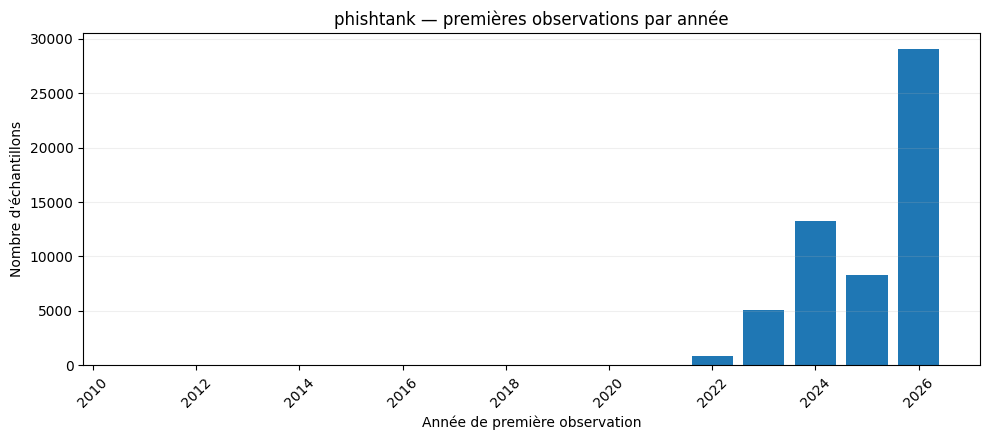

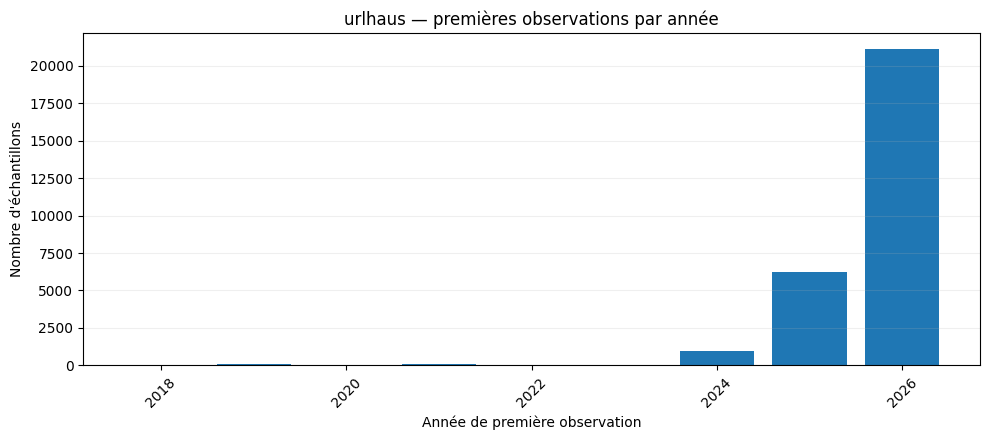

In [32]:
def plot_yearly_source_distribution(source: str) -> None:
    source_counts = yearly_counts[yearly_counts["source"] == source]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(source_counts["observation_year"], source_counts["count"])
    ax.set_title(f"{source} — premières observations par année")
    ax.set_xlabel("Année de première observation")
    ax.set_ylabel("Nombre d'échantillons")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


for source in THREAT_SOURCES:
    plot_yearly_source_distribution(source)

### Interprétation visuelle des distributions temporelles

Les graphiques rendent visible le même phénomène que la table :

- PhishTank possède une histoire longue mais un volume très concentré sur 2024–2026 ;
- URLhaus présente une concentration encore plus forte sur 2025–2026, avec un pic dominant en 2026.

Le graphique URLhaus montre en particulier qu'un découpage naïf par année aurait un effet beaucoup plus sévère sur la classe malware que sur phishing.

La stratégie temporelle n'est donc pas abandonnée : elle devient un **stress test de généralisation temporelle**, distinct du baseline.

### Groupes qui traversent plusieurs périodes

Un groupe peut contenir plusieurs URL observées à des dates différentes. Si nous faisions un split ligne par ligne, une même infrastructure/domaine pourrait alors contaminer train et test.

Le futur split temporel devra donc être **group-aware**. Nous quantifions ici la durée couverte par chaque groupe, sans afficher son identifiant.

In [33]:
temporal_group_span = (
    threat_df.groupby(["source", "group_key"], observed=True)
    .agg(
        first_seen=("first_observed_at", "min"),
        last_seen=("first_observed_at", "max"),
        sample_count=("sample_id", "size"),
    )
    .reset_index()
)

temporal_group_span["span_days"] = (
    temporal_group_span["last_seen"] - temporal_group_span["first_seen"]
).dt.total_seconds() / 86_400

temporal_group_span["spans_multiple_years"] = (
    temporal_group_span["first_seen"].dt.year
    != temporal_group_span["last_seen"].dt.year
)

temporal_group_summary = (
    temporal_group_span.groupby("source", observed=True)
    .agg(
        groups=("group_key", "size"),
        mean_group_size=("sample_count", "mean"),
        max_group_size=("sample_count", "max"),
        median_span_days=("span_days", "median"),
        p95_span_days=("span_days", lambda s: s.quantile(0.95)),
        max_span_days=("span_days", "max"),
        groups_spanning_multiple_years=("spans_multiple_years", "sum"),
    )
)

temporal_group_summary["pct_groups_spanning_multiple_years"] = (
    100
    * temporal_group_summary["groups_spanning_multiple_years"]
    / temporal_group_summary["groups"]
)

display(temporal_group_summary)

,groups,mean_group_size,max_group_size,median_span_days,p95_span_days,max_span_days,groups_spanning_multiple_years,pct_groups_spanning_multiple_years
source,,,,,,,,
phishtank,24803,2.284724,4584,0.000000,0.020647,"2,934.221875",256,1.032133
urlhaus,7090,4.032581,5489,0.000093,12.948306,"2,356.841007",98,1.382228


### Interprétation — groupes et durée temporelle

La majorité des groupes ne traverse pas plusieurs années :

- PhishTank : `256 / 24 803` groupes, soit `1.03 %` ;
- URLhaus : `98 / 7 090`, soit `1.38 %`.

La médiane de `span_days` est pratiquement nulle pour les deux sources.

Le p95 reste également limité :

- PhishTank : `0.020647` jour ;
- URLhaus : `12.948306` jours.

Il existe cependant quelques groupes extrêmes :

- maximum PhishTank : `2 934.22` jours ;
- maximum URLhaus : `2 356.84` jours.

### Conséquence

Un futur split temporel **group-aware** est techniquement faisable pour l'immense majorité des groupes, mais il devra définir une politique explicite pour les rares domaines couvrant plusieurs périodes.

Pour le baseline actuel, cette complexité n'est pas nécessaire : `group_key` sera respecté strictement avec un split stratifié non temporel.

## 13. Décision de split pour le baseline

### Stratégie retenue

Le premier benchmark utilise :

- `StratifiedGroupKFold` avec `5` folds ;
- `shuffle=True` ;
- `random_state=42` ;
- environ `80 %` train / `20 %` test ;
- aucune validation dédiée ;
- aucune présence d'un même `group_key` dans train et test.

Les cinq folds produits par le même seed sont audités uniquement sur leur **qualité structurelle**. Le fold retenu est celui dont les proportions de test par classe sont les plus proches de `20 %`.

Aucune performance de modèle n'intervient dans ce choix.

### Pourquoi ne pas utiliser le split temporel comme baseline ?

Les distributions temporelles de PhishTank et URLhaus sont trop différentes :

- PhishTank possède davantage d'historique exploitable ;
- URLhaus est très concentré sur 2025–2026 ;
- la classe benign provient d'un snapshot HTTP Archive de juillet 2026 et ne possède pas un historique comparable.

Un split temporel mélangerait donc « capacité de classification » et « changement de distribution propre aux sources ».

Nous le conserverons comme seconde expérience de robustesse.

### Déséquilibre des classes

Le test reste **intact** après le split afin de mesurer le comportement du modèle sur la population réellement disponible post-quarantaine.

Seul le train sera équilibré :

1. calcul du nombre d'observations de la plus petite classe du train ;
2. conservation de tous les groupes de cette classe ;
3. sous-échantillonnage déterministe des autres classes ;
4. sélection uniquement de `group_key` complets.

L'égalité exacte n'est pas prioritaire sur l'intégrité des groupes : le nombre final peut différer légèrement de la cible.

### Validation

Le baseline est volontairement figé et aucune recherche d'hyperparamètres n'est réalisée.

Nous n'utilisons donc pas de validation dédiée pour cette première expérience.

Si nous commençons ensuite à comparer :

- plusieurs modèles ;
- plusieurs valeurs de `C` ;
- plusieurs transformations (`log1p`, `RobustScaler`, etc.) ;

la sélection devra se faire par **cross-validation group-aware à l'intérieur du train**, sans réutiliser le test.

In [34]:
# Rapport synthétique du dataset réellement admissible
# au futur split.
#
# Aucun sample_id ou group_key n'est exposé.

transformation_candidates_for_later = []

if not transformation_report.empty:
    transformation_candidates_for_later = (
        transformation_report.loc[
            transformation_report[
                "candidate_for_model_comparison"
            ],
            "feature",
        ]
        .sort_values()
        .tolist()
    )


split_numeric_missing_total = int(
    split_df[
        FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
)

split_numeric_values = (
    split_df[
        FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)

split_non_finite_total = int(
    (
        ~np.isfinite(
            split_numeric_values
        )
    ).sum()
)


pre_split_report = pd.Series(
    {
        "original_pool_rows": (
            len(df)
        ),
        "quarantined_rows": (
            len(shared_group_rows)
        ),
        "split_ready_rows": (
            len(split_df)
        ),
        "classes": sorted(
            split_df[
                "label_code"
            ]
            .unique()
            .tolist()
        ),
        "unique_groups": int(
            split_df[
                "group_key"
            ].nunique()
        ),
        "cross_label_groups": int(
            shared_label_groups
        ),
        "missing_numeric_values": (
            split_numeric_missing_total
        ),
        "non_finite_numeric_values": (
            split_non_finite_total
        ),
        "already_split_rows": int(
            split_df[
                "split"
            ]
            .notna()
            .sum()
        ),
        (
            "log1p_candidates_from_full_pool_"
            "for_later_revalidation"
        ): (
            transformation_candidates_for_later
        ),
        "fixed_seed_for_future_split": (
            RANDOM_SEED
        ),
    },
    name="value",
)

display(
    pre_split_report.to_frame()
)

,value
original_pool_rows,155818
quarantined_rows,12126
split_ready_rows,143692
classes,"[benign, malware, phishing]"
unique_groups,85165
cross_label_groups,0
missing_numeric_values,0
non_finite_numeric_values,0
already_split_rows,0
log1p_candidates_from_full_pool_for_later_revalidation,"[digit_count, dot_count, path_segment_count, s..."


### Interprétation — état final avant split

La population admissible au split contient :

- `143 692` observations après quarantaine ;
- `85 165` groupes uniques ;
- `0` groupe partagé entre plusieurs labels ;
- `0` valeur numérique manquante ;
- `0` valeur numérique non finie ;
- `0` observation déjà affectée à un split.

Le seed de reproductibilité est fixé à `42`.

Le dataset satisfait donc les préconditions nécessaires pour construire un premier split group-aware.

Les transformations `log1p` identifiées précédemment restent des **candidates d'amélioration** et ne sont pas utilisées dans le baseline afin de ne pas sélectionner un preprocessing à partir du test.

In [35]:
# La base n'est plus nécessaire pour le split et le training.
# Les DataFrames restent disponibles en mémoire.
engine.dispose()
print(
    "Engine PostgreSQL libéré. "
    "Split et baseline poursuivis uniquement en mémoire."
)

Engine PostgreSQL libéré. Split et baseline poursuivis uniquement en mémoire.


## 15. Dépendances ML et protocole du baseline

Cette partie ne touche plus PostgreSQL.

Le baseline utilise `scikit-learn` avec une stratégie simple :

- split `StratifiedGroupKFold` ;
- seed fixe `42` ;
- balancing uniquement du train et uniquement par groupes complets ;
- `StandardScaler` ajusté exclusivement sur le train ;
- `LogisticRegression` comme baseline interprétable ;
- aucun tuning ;
- aucun `log1p` dans cette première référence ;
- un `DummyClassifier` uniquement comme plancher de comparaison.

Le choix de ne pas utiliser immédiatement les transformations `log1p` évite de transformer le test en outil de sélection de preprocessing.

In [36]:
import math
import time
import warnings

try:
    import sklearn
    from sklearn.dummy import DummyClassifier
    from sklearn.exceptions import ConvergenceWarning
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
        f1_score,
        log_loss,
    )
    from sklearn.model_selection import StratifiedGroupKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
except ImportError as exc:
    raise RuntimeError(
        "Dépendance ML manquante. Installer explicitement "
        "scikit-learn dans l'environnement du projet avant "
        "d'exécuter la partie baseline."
    ) from exc

LABEL_ORDER = [
    "benign",
    "phishing",
    "malware",
]

TEST_FRACTION_TARGET = 0.20
N_SPLIT_FOLDS = 5
BALANCE_TRIALS = 32

print(f"scikit-learn: {sklearn.__version__}")
print(f"Seed split/balancing: {RANDOM_SEED}")
print(
    "Validation dédiée: non "
    "(baseline figé, sans recherche d'hyperparamètres)"
)

scikit-learn: 1.6.1
Seed split/balancing: 42
Validation dédiée: non (baseline figé, sans recherche d'hyperparamètres)


## 16. Construire le split group-aware 80/20

`StratifiedGroupKFold` cherche à préserver la distribution des classes tout en gardant chaque groupe dans un seul fold.

À cause des très grands groupes malware/phishing observés précédemment, un ratio exactement égal à `20 %` par classe n'est pas garanti.

Nous construisons les 5 folds avec le même seed et choisissons uniquement le fold présentant la meilleure proximité **structurelle** avec la cible `20 %`.

La performance du modèle n'intervient jamais dans ce choix.

In [37]:
# Ordre stable avant le splitter afin de rendre l'expérience
# reproductible même si PostgreSQL renvoie les lignes dans
# un ordre différent lors d'une nouvelle exécution.
split_source_df = (
    split_df
    .sort_values(
        [
            "label_code",
            "group_key",
            "sample_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

y_for_split = (
    split_source_df[
        "label_code"
    ]
    .to_numpy()
)

groups_for_split = (
    split_source_df[
        "group_key"
    ]
    .to_numpy()
)

splitter = StratifiedGroupKFold(
    n_splits=N_SPLIT_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

class_totals_for_split = (
    split_source_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

candidate_rows = []
candidate_indices = {}

for fold_id, (
    candidate_train_idx,
    candidate_test_idx,
) in enumerate(
    splitter.split(
        X=np.zeros(
            (
                len(split_source_df),
                1,
            ),
            dtype=np.uint8,
        ),
        y=y_for_split,
        groups=groups_for_split,
    )
):
    candidate_test_counts = (
        split_source_df
        .iloc[
            candidate_test_idx
        ][
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    class_test_fractions = (
        candidate_test_counts
        / class_totals_for_split
    )

    deviations = (
        class_test_fractions
        - TEST_FRACTION_TARGET
    ).abs()

    candidate_rows.append(
        {
            "fold_id": fold_id,
            "test_rows": int(
                len(
                    candidate_test_idx
                )
            ),
            "test_fraction_global": (
                len(candidate_test_idx)
                / len(split_source_df)
            ),
            "benign_test_fraction": float(
                class_test_fractions[
                    "benign"
                ]
            ),
            "phishing_test_fraction": float(
                class_test_fractions[
                    "phishing"
                ]
            ),
            "malware_test_fraction": float(
                class_test_fractions[
                    "malware"
                ]
            ),
            "max_abs_class_deviation": float(
                deviations.max()
            ),
            "mean_abs_class_deviation": float(
                deviations.mean()
            ),
        }
    )

    candidate_indices[
        fold_id
    ] = (
        candidate_train_idx,
        candidate_test_idx,
    )


candidate_split_quality = (
    pd.DataFrame(
        candidate_rows
    )
    .sort_values(
        [
            "max_abs_class_deviation",
            "mean_abs_class_deviation",
            "fold_id",
        ]
    )
    .reset_index(drop=True)
)

display(
    candidate_split_quality
)

selected_fold_id = int(
    candidate_split_quality.loc[
        0,
        "fold_id",
    ]
)

(
    train_pool_idx,
    test_idx,
) = candidate_indices[
    selected_fold_id
]

train_pool_df = (
    split_source_df
    .iloc[
        train_pool_idx
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    split_source_df
    .iloc[
        test_idx
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Fold structurel retenu : "
    f"{selected_fold_id}"
)
print(
    "Train pool : "
    f"{len(train_pool_df):,}"
)
print(
    "Test : "
    f"{len(test_df):,}"
)

,fold_id,test_rows,test_fraction_global,benign_test_fraction,phishing_test_fraction,malware_test_fraction,max_abs_class_deviation,mean_abs_class_deviation
0,3,29561,0.205725,0.202523,0.232812,0.158581,0.041419,0.025584
1,1,26339,0.183302,0.203361,0.154038,0.200308,0.045962,0.016544
2,0,32666,0.227333,0.205209,0.272023,0.183974,0.072023,0.031086
3,4,25359,0.176482,0.185306,0.201613,0.108636,0.091364,0.035890
4,2,29767,0.207158,0.203601,0.139514,0.348501,0.148501,0.070863


Fold structurel retenu : 3
Train pool : 114,131
Test : 29,561


### Audit obligatoire du split

Avant tout entraînement :

- aucun `group_key` ne doit traverser train/test ;
- aucun `sample_id` ne doit traverser train/test ;
- les trois classes doivent être présentes ;
- les volumes réellement obtenus doivent être affichés.

Les identifiants de groupes eux-mêmes ne sont jamais imprimés.

In [38]:
train_groups = set(
    train_pool_df[
        "group_key"
    ]
    .unique()
)

test_groups = set(
    test_df[
        "group_key"
    ]
    .unique()
)

group_overlap_count = len(
    train_groups
    & test_groups
)

sample_overlap_count = len(
    set(
        train_pool_df[
            "sample_id"
        ]
        .unique()
    )
    & set(
        test_df[
            "sample_id"
        ]
        .unique()
    )
)

if group_overlap_count != 0:
    raise RuntimeError(
        "Fuite détectée : au moins "
        "un group_key traverse train/test."
    )

if sample_overlap_count != 0:
    raise RuntimeError(
        "Fuite détectée : au moins "
        "un sample_id traverse train/test."
    )


def partition_class_summary(
    frame: pd.DataFrame,
    partition: str,
) -> pd.DataFrame:
    counts = (
        frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    result = pd.DataFrame(
        {
            "partition": (
                partition
            ),
            "label_code": (
                counts.index
            ),
            "count": (
                counts.values
            ),
        }
    )

    result[
        "pct_within_partition"
    ] = (
        100
        * result[
            "count"
        ]
        / result[
            "count"
        ].sum()
    )

    return result


split_class_summary = (
    pd.concat(
        [
            partition_class_summary(
                train_pool_df,
                "train_pool",
            ),
            partition_class_summary(
                test_df,
                "test",
            ),
        ],
        ignore_index=True,
    )
)

display(
    split_class_summary
)

print(
    "Chevauchement group_key : "
    f"{group_overlap_count}"
)

print(
    "Chevauchement sample_id : "
    f"{sample_overlap_count}"
)

,partition,label_code,count,pct_within_partition
0,train_pool,benign,46599,40.829398
1,train_pool,phishing,43475,38.092192
2,train_pool,malware,24057,21.078410
3,test,benign,11834,40.032475
4,test,phishing,13193,44.629749
5,test,malware,4534,15.337776


Chevauchement group_key : 0
Chevauchement sample_id : 0


### Audit temporel du split non temporel

Le baseline mélange volontairement les périodes.

Nous vérifions néanmoins que train et test conservent une couverture temporelle comparable pour PhishTank et URLhaus.

Cette cellule est un contrôle de distribution, pas un critère d'optimisation du test.

In [39]:
def temporal_partition_quantiles(
    frame: pd.DataFrame,
    partition: str,
) -> pd.DataFrame:
    threat_partition = (
        frame.loc[
            frame[
                "source"
            ].isin(
                THREAT_SOURCES
            )
        ]
        .copy()
    )

    rows = []

    for source, source_frame in (
        threat_partition.groupby(
            "source",
            observed=True,
        )
    ):
        dates = (
            source_frame[
                "first_observed_at"
            ]
            .dropna()
            .sort_values()
        )

        rows.append(
            {
                "partition": (
                    partition
                ),
                "source": source,
                "count": int(
                    len(dates)
                ),
                "min": dates.min(),
                "median": dates.quantile(
                    0.50
                ),
                "q90": dates.quantile(
                    0.90
                ),
                "max": dates.max(),
            }
        )

    return pd.DataFrame(
        rows
    )


split_temporal_quantiles = (
    pd.concat(
        [
            temporal_partition_quantiles(
                train_pool_df,
                "train_pool",
            ),
            temporal_partition_quantiles(
                test_df,
                "test",
            ),
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "source",
            "partition",
        ]
    )
)

display(
    split_temporal_quantiles
)

,partition,source,count,min,median,q90,max
2,test,phishtank,13193,2013-05-28 15:59:31+00:00,2025-11-02 11:10:33+00:00,2026-06-29 15:22:11.400000+00:00,2026-07-31 12:53:07+00:00
0,train_pool,phishtank,43475,2011-02-18 10:50:32+00:00,2026-01-27 09:27:29+00:00,2026-07-07 20:29:59.600000+00:00,2026-07-31 12:38:39+00:00
3,test,urlhaus,4534,2018-10-09 05:59:03+00:00,2026-07-20 01:15:54+00:00,2026-08-04 21:11:17+00:00,2026-08-10 13:14:40+00:00
1,train_pool,urlhaus,24057,2018-06-05 22:09:14+00:00,2026-06-22 14:33:36+00:00,2026-08-03 09:41:42+00:00,2026-08-10 13:51:21+00:00


## 17. Équilibrer uniquement le train

Le test n'est pas équilibré artificiellement : il reste représentatif de la population post-quarantaine produite par le split.

Pour le train, nous visons le nombre d'observations de la classe la moins représentée.

La sélection respecte toujours des `group_key` complets. Plusieurs permutations déterministes sont testées pour approcher la cible sans casser un groupe.

Cette opération reste légère : sa complexité dépend du nombre de groupes, pas du nombre de combinaisons possibles. Nous n'utilisons pas de problème de subset-sum exact ou d'optimisation coûteuse.

In [40]:
def select_group_subset_near_target(
    class_frame: pd.DataFrame,
    *,
    target_count: int,
    seed: int,
    trials: int = BALANCE_TRIALS,
) -> tuple[
    pd.DataFrame,
    dict[str, int | float],
]:
    """
    Sélectionne uniquement des groupes complets.

    Plusieurs permutations déterministes sont testées et
    on conserve celle dont le nombre d'observations est
    le plus proche de la cible.

    Complexité : O(trials * G), où G est le nombre de
    groupes de la classe.
    """
    group_sizes = (
        class_frame
        .groupby(
            "group_key",
            observed=True,
        )
        .size()
    )

    source_count = int(
        group_sizes.sum()
    )

    if source_count <= target_count:
        selected = (
            class_frame
            .copy()
            .reset_index(drop=True)
        )

        return (
            selected,
            {
                "source_count": (
                    source_count
                ),
                "target_count": int(
                    target_count
                ),
                "selected_count": (
                    source_count
                ),
                "absolute_deviation": int(
                    abs(
                        source_count
                        - target_count
                    )
                ),
                "selected_groups": int(
                    group_sizes.size
                ),
            },
        )

    group_keys = (
        group_sizes.index
        .to_numpy()
    )

    sizes = (
        group_sizes
        .to_numpy(
            dtype=np.int64
        )
    )

    best_group_indices = None
    best_count = None
    best_deviation = math.inf

    seed_sequence = (
        np.random.SeedSequence(
            seed
        )
    )

    for child_seed in (
        seed_sequence.spawn(
            trials
        )
    ):
        rng = (
            np.random.default_rng(
                child_seed
            )
        )

        order = rng.permutation(
            len(group_keys)
        )

        cumulative = np.cumsum(
            sizes[
                order
            ]
        )

        candidate_counts = (
            np.concatenate(
                (
                    np.array(
                        [0],
                        dtype=np.int64,
                    ),
                    cumulative,
                )
            )
        )

        position = int(
            np.argmin(
                np.abs(
                    candidate_counts
                    - target_count
                )
            )
        )

        selected_count = int(
            candidate_counts[
                position
            ]
        )

        deviation = abs(
            selected_count
            - target_count
        )

        if deviation < best_deviation:
            best_deviation = (
                deviation
            )

            best_count = (
                selected_count
            )

            best_group_indices = (
                order[
                    :position
                ]
            )

        if best_deviation == 0:
            break

    if (
        best_group_indices
        is None
        or best_count is None
    ):
        raise RuntimeError(
            "Impossible de construire "
            "le sous-ensemble group-aware."
        )

    selected_group_keys = set(
        group_keys[
            best_group_indices
        ].tolist()
    )

    selected = (
        class_frame.loc[
            class_frame[
                "group_key"
            ].isin(
                selected_group_keys
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    return (
        selected,
        {
            "source_count": (
                source_count
            ),
            "target_count": int(
                target_count
            ),
            "selected_count": int(
                len(selected)
            ),
            "absolute_deviation": int(
                abs(
                    len(selected)
                    - target_count
                )
            ),
            "selected_groups": int(
                selected[
                    "group_key"
                ].nunique()
            ),
        },
    )


train_pool_class_counts = (
    train_pool_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

balanced_train_target = int(
    train_pool_class_counts.min()
)

balanced_parts = []
balance_rows = []

for label_index, label in enumerate(
    LABEL_ORDER
):
    class_frame = (
        train_pool_df.loc[
            train_pool_df[
                "label_code"
            ]
            == label
        ]
        .copy()
    )

    (
        selected_class_frame,
        diagnostics,
    ) = (
        select_group_subset_near_target(
            class_frame,
            target_count=(
                balanced_train_target
            ),
            seed=(
                RANDOM_SEED
                + 1_000
                * label_index
            ),
        )
    )

    balanced_parts.append(
        selected_class_frame
    )

    balance_rows.append(
        {
            "label_code": label,
            **diagnostics,
        }
    )


train_df = (
    pd.concat(
        balanced_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "label_code",
            "group_key",
            "sample_id",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

training_balance_report = (
    pd.DataFrame(
        balance_rows
    )
    .set_index(
        "label_code"
    )
)

training_balance_report[
    "kept_pct"
] = (
    100
    * training_balance_report[
        "selected_count"
    ]
    / training_balance_report[
        "source_count"
    ]
)

display(
    training_balance_report
)

print(
    "Cible train par classe : "
    f"{balanced_train_target:,}"
)

print(
    "Train équilibré final : "
    f"{len(train_df):,}"
)

print(
    "Test laissé intact : "
    f"{len(test_df):,}"
)

,source_count,target_count,selected_count,absolute_deviation,selected_groups,kept_pct
label_code,,,,,,
benign,46599,24057,24057,0,21891,51.625571
phishing,43475,24057,24057,0,11520,55.335250
malware,24057,24057,24057,0,5640,100.000000


Cible train par classe : 24,057
Train équilibré final : 72,171
Test laissé intact : 29,561


### Lecture du rapport de balancing

Après exécution, vérifier :

- la cible commune ;
- le nombre réellement retenu par classe ;
- l'écart absolu à la cible ;
- le pourcentage du train original conservé.

Un léger écart est acceptable si l'alternative consiste à couper un `group_key`.

Le train original reste disponible dans `train_pool_df` afin de pouvoir comparer plus tard ce baseline équilibré à une stratégie utilisant toutes les données avec pondération de classes.

## 18. Construire `X_train`, `y_train`, `X_test`, `y_test`

Le modèle reçoit **exactement les 13 features V1**.

Sont explicitement exclus :

- `source` ;
- `group_key` ;
- `sample_id` ;
- `observed_at` ;
- toute information d'identité ou de provenance.

Le test est maintenant considéré comme verrouillé : aucune transformation ou décision de paramétrage ne doit être choisie à partir de ses résultats.

In [41]:
X_train = (
    train_df[
        FEATURE_COLUMNS
    ]
    .astype(
        float
    )
    .copy()
)

y_train = (
    train_df[
        "label_code"
    ]
    .copy()
)

X_test = (
    test_df[
        FEATURE_COLUMNS
    ]
    .astype(
        float
    )
    .copy()
)

y_test = (
    test_df[
        "label_code"
    ]
    .copy()
)

for matrix_name, matrix in (
    ("X_train", X_train),
    ("X_test", X_test),
):
    if matrix.isna().any().any():
        raise RuntimeError(
            f"{matrix_name} contient "
            "des valeurs manquantes."
        )

    if not np.isfinite(
        matrix.to_numpy(
            dtype=float
        )
    ).all():
        raise RuntimeError(
            f"{matrix_name} contient "
            "des valeurs non finies."
        )

print(
    "X_train : "
    f"{X_train.shape}"
)

print(
    "X_test : "
    f"{X_test.shape}"
)

print(
    "Features utilisées : "
    f"{len(FEATURE_COLUMNS)}"
)

X_train : (72171, 13)
X_test : (29561, 13)
Features utilisées : 13


In [42]:
def evaluate_classifier(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    *,
    model_name: str,
) -> tuple[
    pd.Series,
    pd.DataFrame,
    np.ndarray,
    np.ndarray,
]:
    y_pred = model.predict(
        X
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(
            y,
            y_pred,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                y_pred,
            )
        ),
        "macro_f1": f1_score(
            y,
            y_pred,
            labels=LABEL_ORDER,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y,
            y_pred,
            labels=LABEL_ORDER,
            average="weighted",
            zero_division=0,
        ),
    }

    if hasattr(
        model,
        "predict_proba",
    ):
        probabilities = (
            model.predict_proba(
                X
            )
        )

        metrics[
            "log_loss"
        ] = log_loss(
            y,
            probabilities,
            labels=model.classes_,
        )

    report = (
        classification_report(
            y,
            y_pred,
            labels=LABEL_ORDER,
            output_dict=True,
            zero_division=0,
        )
    )

    per_class_report = (
        pd.DataFrame(
            {
                label: (
                    report[
                        label
                    ]
                )
                for label
                in LABEL_ORDER
            }
        )
        .T[
            [
                "precision",
                "recall",
                "f1-score",
                "support",
            ]
        ]
    )

    matrix_raw = (
        confusion_matrix(
            y,
            y_pred,
            labels=LABEL_ORDER,
        )
    )

    matrix_normalized = (
        confusion_matrix(
            y,
            y_pred,
            labels=LABEL_ORDER,
            normalize="true",
        )
    )

    return (
        pd.Series(
            metrics,
            name=model_name,
        ),
        per_class_report,
        matrix_raw,
        matrix_normalized,
    )

## 19. Baseline : régression logistique

### Pourquoi ce modèle ?

La régression logistique est :

- rapide sur 13 variables numériques ;
- interprétable ;
- adaptée à un premier benchmark multiclasses ;
- suffisamment simple pour révéler si les 13 features contiennent déjà un signal exploitable.

Le `StandardScaler` est inclus dans un `Pipeline`, ce qui garantit qu'il est ajusté uniquement sur `X_train`.

Aucune recherche de `C`, de solver ou d'autre paramètre n'est réalisée dans ce notebook.

`max_iter=1000` fixe uniquement un budget de convergence raisonnable ; les warnings de convergence sont explicitement contrôlés.

In [43]:
# Plancher de comparaison : ne regarde pas les features.
dummy_model = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_SEED,
)

dummy_model.fit(
    X_train,
    y_train,
)


# Baseline réel :
# - 13 features V1 brutes ;
# - StandardScaler ajusté uniquement sur train ;
# - LogisticRegression sans recherche d'hyperparamètres.
baseline_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                max_iter=1_000,
                C=1.0,
            ),
        ),
    ]
)

fit_started_at = (
    time.perf_counter()
)

with warnings.catch_warnings(
    record=True
) as caught_warnings:
    warnings.simplefilter(
        "always",
        ConvergenceWarning,
    )

    baseline_model.fit(
        X_train,
        y_train,
    )

fit_duration_seconds = (
    time.perf_counter()
    - fit_started_at
)

convergence_warnings = [
    warning
    for warning
    in caught_warnings
    if issubclass(
        warning.category,
        ConvergenceWarning,
    )
]

print(
    "Baseline entraîné en "
    f"{fit_duration_seconds:.3f} s"
)

print(
    "Convergence warnings : "
    f"{len(convergence_warnings)}"
)

classifier = (
    baseline_model
    .named_steps[
        "classifier"
    ]
)

print(
    "Itérations solveur : "
    f"{classifier.n_iter_.tolist()}"
)

Baseline entraîné en 3.386 s
Convergence warnings : 0
Itérations solveur : [58]


## 20. Mesures de performance

Nous comparons :

1. un `DummyClassifier` stratifié, qui ignore complètement les features ;
2. le baseline Logistic Regression sur le train ;
3. le baseline Logistic Regression sur le test.

Les métriques principales sont :

- macro-F1 ;
- balanced accuracy ;
- precision / recall / F1 par classe ;
- accuracy et weighted-F1 comme informations secondaires ;
- log-loss puisque le modèle produit des probabilités.

Le **macro-F1** reste la métrique de référence car chaque classe contribue avec le même poids, indépendamment de sa fréquence dans le test.

In [44]:
(
    dummy_test_metrics,
    dummy_test_report,
    dummy_confusion_raw,
    dummy_confusion_normalized,
) = evaluate_classifier(
    dummy_model,
    X_test,
    y_test,
    model_name=(
        "dummy_stratified_test"
    ),
)

(
    baseline_train_metrics,
    baseline_train_report,
    baseline_train_confusion_raw,
    baseline_train_confusion_normalized,
) = evaluate_classifier(
    baseline_model,
    X_train,
    y_train,
    model_name=(
        "logistic_regression_train"
    ),
)

(
    baseline_test_metrics,
    baseline_test_report,
    baseline_test_confusion_raw,
    baseline_test_confusion_normalized,
) = evaluate_classifier(
    baseline_model,
    X_test,
    y_test,
    model_name=(
        "logistic_regression_test"
    ),
)

metrics_comparison = (
    pd.DataFrame(
        [
            dummy_test_metrics,
            baseline_train_metrics,
            baseline_test_metrics,
        ]
    )
    .set_index(
        "model"
    )
)

display(
    metrics_comparison
)

print(
    "=== Rapport par classe — test ==="
)

display(
    baseline_test_report
)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
model,,,,,
dummy_stratified_test,0.335205,0.335686,0.320449,0.350093,23.961634
logistic_regression_train,0.841474,0.841474,0.841540,0.841540,0.417535
logistic_regression_test,0.701938,0.744012,0.728285,0.692110,0.548133


=== Rapport par classe — test ===


,precision,recall,f1-score,support
benign,0.604342,0.879753,0.716493,"11,834.000000"
phishing,0.836399,0.485940,0.614728,"13,193.000000"
malware,0.841294,0.866343,0.853635,"4,534.000000"


### Comment lire les résultats

Après exécution :

- le gain de macro-F1 par rapport au Dummy indique la valeur ajoutée réelle des features ;
- l'écart train/test permet d'observer un éventuel problème de généralisation ;
- les métriques par classe permettent d'identifier si malware, phishing ou benign reste difficile ;
- la balanced accuracy complète le macro-F1 en donnant le même poids au rappel de chaque classe.

Aucun seuil arbitraire de « bon modèle » n'est imposé ici : le baseline sert avant tout de référence mesurable pour les améliorations futures.

## 21. Matrices de confusion

La matrice brute montre les volumes d'erreurs.

La matrice normalisée par classe réelle montre les taux de confusion indépendamment du nombre d'observations de chaque classe.

Cette deuxième vue est particulièrement importante puisque le test n'est volontairement pas équilibré.

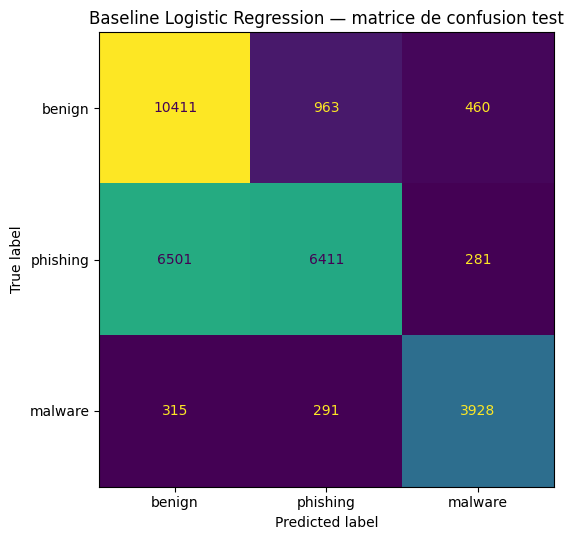

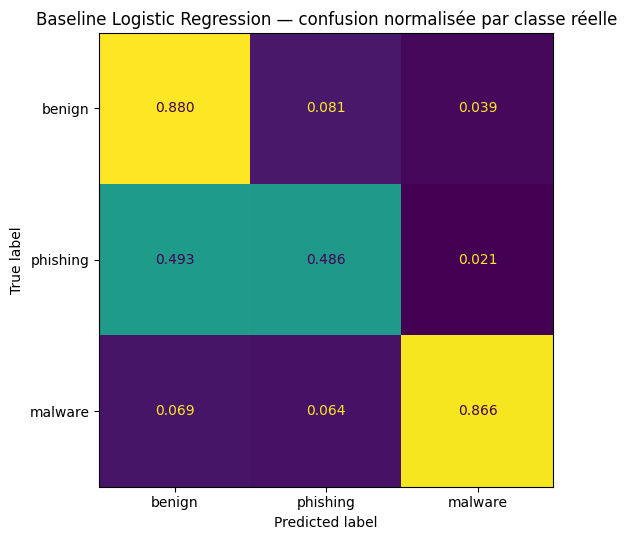

In [45]:
fig, ax = plt.subplots(
    figsize=(
        6.5,
        5.5,
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        baseline_test_confusion_raw
    ),
    display_labels=LABEL_ORDER,
).plot(
    ax=ax,
    colorbar=False,
    values_format="d",
)

ax.set_title(
    "Baseline Logistic Regression — "
    "matrice de confusion test"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(
        6.5,
        5.5,
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        baseline_test_confusion_normalized
    ),
    display_labels=LABEL_ORDER,
).plot(
    ax=ax,
    colorbar=False,
    values_format=".3f",
)

ax.set_title(
    "Baseline Logistic Regression — "
    "confusion normalisée par classe réelle"
)

plt.tight_layout()
plt.show()

### Interprétation attendue des matrices

Après exécution, identifier en priorité :

- la classe possédant le plus faible rappel ;
- la paire de classes la plus souvent confondue ;
- les erreurs asymétriques, par exemple si phishing est souvent prédit benign mais pas l'inverse.

Ces observations guideront l'étape suivante : transformations, modèles non linéaires ou amélioration du dataset.

Elles ne doivent pas être utilisées pour réentraîner immédiatement le modèle sur le test.

## 22. Coefficients du baseline

Comme les variables ont été standardisées, l'amplitude absolue des coefficients devient plus comparable entre features.

Les coefficients restent toutefois une indication du comportement du modèle linéaire, pas une preuve causale.

Nous n'affichons que des noms de features et des coefficients agrégés : aucune donnée d'URL ou de domaine n'est exposée.

In [46]:
classifier = (
    baseline_model
    .named_steps[
        "classifier"
    ]
)

coefficient_table = (
    pd.DataFrame(
        classifier.coef_,
        index=classifier.classes_,
        columns=FEATURE_COLUMNS,
    )
)

coefficient_long = (
    coefficient_table
    .rename_axis(
        "label_code"
    )
    .reset_index()
    .melt(
        id_vars=(
            "label_code"
        ),
        var_name="feature",
        value_name="coefficient",
    )
)

coefficient_long[
    "absolute_coefficient"
] = (
    coefficient_long[
        "coefficient"
    ].abs()
)

top_coefficients_by_class = (
    coefficient_long
    .sort_values(
        [
            "label_code",
            "absolute_coefficient",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "label_code",
        observed=True,
    )
    .head(6)
    .reset_index(drop=True)
)

display(
    top_coefficients_by_class
)

,label_code,feature,coefficient,absolute_coefficient
0,benign,special_char_count,3.684302,3.684302
1,benign,special_char_ratio,-2.410681,2.410681
2,benign,url_length,-2.078976,2.078976
3,benign,path_segment_count_special_char_ratio_product,1.737624,1.737624
4,benign,digit_count,-1.418441,1.418441
5,benign,path_segment_count,-1.303704,1.303704
6,malware,special_char_count,-2.486708,2.486708
7,malware,special_char_ratio,2.045333,2.045333
8,malware,dot_count,1.732529,1.732529
9,malware,mean_hostname_label_length,1.420748,1.420748


## 23. Résumé automatique du baseline

Cette cellule extrait les observations essentielles sans imposer de seuil arbitraire :

- macro-F1 test ;
- gain par rapport au Dummy ;
- écart macro-F1 train/test ;
- classe la plus faible et la plus forte ;
- confusion normalisée dominante ;
- éventuels warnings de convergence.

Le tableau produit devra être utilisé pour rédiger la conclusion scientifique du baseline après exécution.

In [47]:
test_macro_f1 = float(
    baseline_test_metrics[
        "macro_f1"
    ]
)

train_macro_f1 = float(
    baseline_train_metrics[
        "macro_f1"
    ]
)

dummy_macro_f1 = float(
    dummy_test_metrics[
        "macro_f1"
    ]
)

per_class_f1 = (
    baseline_test_report[
        "f1-score"
    ]
    .astype(float)
)

worst_class = str(
    per_class_f1.idxmin()
)

best_class = str(
    per_class_f1.idxmax()
)

off_diagonal = (
    baseline_test_confusion_normalized
    .copy()
)

np.fill_diagonal(
    off_diagonal,
    0.0,
)

worst_confusion_index = (
    np.unravel_index(
        np.argmax(
            off_diagonal
        ),
        off_diagonal.shape,
    )
)

most_confused_true_class = (
    LABEL_ORDER[
        worst_confusion_index[
            0
        ]
    ]
)

most_confused_predicted_class = (
    LABEL_ORDER[
        worst_confusion_index[
            1
        ]
    ]
)

baseline_conclusion = pd.Series(
    {
        "test_macro_f1": (
            test_macro_f1
        ),
        "dummy_test_macro_f1": (
            dummy_macro_f1
        ),
        "macro_f1_gain_vs_dummy": (
            test_macro_f1
            - dummy_macro_f1
        ),
        "train_macro_f1": (
            train_macro_f1
        ),
        "train_test_macro_f1_gap": (
            train_macro_f1
            - test_macro_f1
        ),
        "test_balanced_accuracy": float(
            baseline_test_metrics[
                "balanced_accuracy"
            ]
        ),
        "worst_test_class_by_f1": (
            worst_class
        ),
        "worst_test_class_f1": float(
            per_class_f1[
                worst_class
            ]
        ),
        "best_test_class_by_f1": (
            best_class
        ),
        "best_test_class_f1": float(
            per_class_f1[
                best_class
            ]
        ),
        "largest_normalized_confusion_true": (
            most_confused_true_class
        ),
        "largest_normalized_confusion_predicted": (
            most_confused_predicted_class
        ),
        "largest_normalized_confusion_rate": float(
            off_diagonal[
                worst_confusion_index
            ]
        ),
        "convergence_warning_count": int(
            len(
                convergence_warnings
            )
        ),
    },
    name="value",
)

display(
    baseline_conclusion.to_frame()
)

,value
test_macro_f1,0.728285
dummy_test_macro_f1,0.320449
macro_f1_gain_vs_dummy,0.407836
train_macro_f1,0.841540
train_test_macro_f1_gap,0.113255
test_balanced_accuracy,0.744012
worst_test_class_by_f1,phishing
worst_test_class_f1,0.614728
best_test_class_by_f1,malware
best_test_class_f1,0.853635


## 25. Sauvegarde du baseline V1

Le baseline est maintenant suffisamment stable pour devenir notre **modèle de référence**.

Nous sauvegardons :

1. le pipeline entraîné complet :
   - `StandardScaler` ;
   - `LogisticRegression` ;
2. l'ordre exact des 13 features ;
3. l'ordre des labels ;
4. les paramètres de reproductibilité ;
5. les principales métriques obtenues sur le test ;
6. un checksum SHA-256 de l'artefact.

L'artefact pourra être rechargé lors des prochaines expériences afin de comparer les nouveaux modèles à exactement la même baseline.

### Sécurité

Le format `joblib` repose sur le mécanisme de sérialisation Python.

Un fichier de modèle provenant d'une source non fiable ne doit **jamais être chargé**, car un artefact Python malveillant peut exécuter du code lors de sa désérialisation.

Seuls les modèles produits et contrôlés par notre pipeline doivent être utilisés.

Aucune URL, aucun `group_key`, aucun `sample_id` et aucune donnée brute du dataset ne sont persistés dans l'artefact.

In [48]:
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib


BASELINE_ARTIFACT_VERSION = "baseline_v1"

MODEL_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "ml"
    / "models"
)

MODEL_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


model_path = (
    MODEL_ARTIFACT_DIR
    / (
        "url_multiclass_logistic_regression_"
        f"{BASELINE_ARTIFACT_VERSION}.joblib"
    )
)

metadata_path = (
    MODEL_ARTIFACT_DIR
    / (
        "url_multiclass_logistic_regression_"
        f"{BASELINE_ARTIFACT_VERSION}.metadata.json"
    )
)


baseline_artifact = {
    "artifact_version": (
        BASELINE_ARTIFACT_VERSION
    ),
    "model": baseline_model,
    "feature_columns": list(
        FEATURE_COLUMNS
    ),
    "label_order": list(
        LABEL_ORDER
    ),
}


joblib.dump(
    baseline_artifact,
    model_path,
    compress=3,
)


def sha256_file(
    path: Path,
) -> str:
    digest = hashlib.sha256()

    with path.open(
        "rb"
    ) as file:
        for chunk in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(
                chunk
            )

    return digest.hexdigest()


model_sha256 = sha256_file(
    model_path
)


baseline_metadata = {
    "artifact_version": (
        BASELINE_ARTIFACT_VERSION
    ),
    "created_at_utc": (
        datetime.now(
            timezone.utc
        )
        .isoformat()
    ),
    "model_type": (
        "LogisticRegression"
    ),
    "pipeline": [
        "StandardScaler",
        "LogisticRegression",
    ],
    "feature_set_version": (
        "2.0.0"
    ),
    "feature_count": (
        len(
            FEATURE_COLUMNS
        )
    ),
    "feature_columns": list(
        FEATURE_COLUMNS
    ),
    "label_order": list(
        LABEL_ORDER
    ),
    "random_seed": (
        RANDOM_SEED
    ),
    "split_strategy": (
        "StratifiedGroupKFold"
    ),
    "split_target": (
        "80/20"
    ),
    "validation_set": False,
    "training_strategy": (
        "group-aware downsampling "
        "to balanced classes"
    ),
    "train_rows": int(
        len(
            train_df
        )
    ),
    "test_rows": int(
        len(
            test_df
        )
    ),
    "metrics": {
        "macro_f1": float(
            baseline_test_metrics[
                "macro_f1"
            ]
        ),
        "balanced_accuracy": float(
            baseline_test_metrics[
                "balanced_accuracy"
            ]
        ),
        "accuracy": float(
            baseline_test_metrics[
                "accuracy"
            ]
        ),
        "weighted_f1": float(
            baseline_test_metrics[
                "weighted_f1"
            ]
        ),
        "log_loss": float(
            baseline_test_metrics[
                "log_loss"
            ]
        ),
    },
    "per_class_f1": {
        label: float(
            baseline_test_report.loc[
                label,
                "f1-score",
            ]
        )
        for label in LABEL_ORDER
    },
    "model_sha256": (
        model_sha256
    ),
}


with metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        baseline_metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )


print(
    "Baseline sauvegardée."
)

print(
    "Model : "
    f"{model_path.relative_to(PROJECT_ROOT)}"
)

print(
    "Metadata : "
    f"{metadata_path.relative_to(PROJECT_ROOT)}"
)

print(
    "SHA-256 : "
    f"{model_sha256}"
)

Baseline sauvegardée.
Model : artifacts\ml\models\url_multiclass_logistic_regression_baseline_v1.joblib
Metadata : artifacts\ml\models\url_multiclass_logistic_regression_baseline_v1.metadata.json
SHA-256 : 78f5c2bedff9c459f8538ab8d4fe5742f411eec12aa611c6b6f261ce10a01048


## Conclusion — Baseline V1 et prochaines expérimentations

Cette première expérience fournit désormais une **baseline reproductible** pour la classification multiclasses des URL en :

- `benign` ;
- `phishing` ;
- `malware`.

L'objectif de cette baseline n'était pas d'obtenir immédiatement le meilleur modèle possible, mais de vérifier si le **Feature Set V1 de 13 variables lexicales** contient suffisamment de signal pour distinguer les trois classes dans des conditions limitant les fuites de données.

---

### 1. Dataset utilisé

Le pool initial contenait :

- `155 818` observations ;
- `85 333` `group_key` distincts ;
- aucune feature manquante ;
- aucune valeur numérique non finie ;
- aucun `sample_id` dupliqué.

L'audit des groupes a cependant identifié :

- `168` `group_key` associés à plusieurs labels ;
- `12 126` observations concernées ;
- soit `7.7822 %` du pool initial.

Ces groupes ont été placés en quarantaine afin qu'un même domaine ou une même IP ne puisse pas représenter plusieurs classes dans le dataset destiné au split.

Après quarantaine :

- observations disponibles : `143 692` ;
- groupes uniques : `85 165` ;
- groupes multi-labels restants : `0`.

La quarantaine n'affecte cependant pas les classes de manière uniforme :

| Classe | Observations retirées | Part retirée |
|---|---:|---:|
| benign | 235 | 0.40 % |
| malware | 1 334 | 4.46 % |
| phishing | 10 557 | 15.70 % |

Cette différence constitue une **limitation méthodologique importante** : le baseline est évalué sur une population composée exclusivement de groupes mono-labels et sous-représente notamment les domaines phishing à comportement mixte.

Le pool original reste conservé et ces groupes pourront ultérieurement servir de dataset de robustesse spécifique.

---

### 2. Choix de la stratégie de split

L'étude temporelle montre que PhishTank et URLhaus possèdent des distributions temporelles très différentes.

Pour PhishTank, malgré un historique remontant à 2011, la majorité des observations est récente :

- 2023 : `5 054` observations ;
- 2024 : `13 243` ;
- 2025 : `8 331` ;
- 2026 : `29 077`.

Pour URLhaus, la concentration récente est encore plus forte :

- 2024 : `961` observations ;
- 2025 : `6 212` ;
- 2026 : `21 141`.

Une frontière temporelle commune aurait donc fortement réduit la quantité de malware disponible dans le train et aurait produit des distributions très différentes entre les classes.

Le split temporel n'est pas abandonné : il sera utilisé plus tard comme **stress test de généralisation temporelle et de concept drift**.

Pour la baseline, la stratégie retenue est donc :

- `StratifiedGroupKFold` ;
- seed fixe `42` ;
- cible approximative `80 % train / 20 % test` ;
- respect strict des `group_key`.

Le split obtenu contient :

- train pool : `114 131` observations ;
- test : `29 561` observations ;
- chevauchement de `group_key` : `0` ;
- chevauchement de `sample_id` : `0`.

Le test représente environ `20.57 %` de la population post-quarantaine.

Les proportions par classe ne peuvent pas être parfaitement stratifiées à cause de certains groupes très volumineux. Le plus grand groupe malware représente notamment environ `19.20 %` de toute cette classe.

L'intégrité des groupes est volontairement prioritaire sur l'obtention d'un ratio exactement égal à `80/20`.

---

### 3. Balancing du train

Le train initial contenait :

- benign : `46 599` observations ;
- phishing : `43 475` ;
- malware : `24 057`.

Pour construire une première baseline simple, les trois classes ont été équilibrées en utilisant la classe la moins représentée comme cible :

`24 057 observations / classe`

Le train utilisé par le modèle contient donc :

`72 171 observations`

avec :

- benign : `24 057` ;
- phishing : `24 057` ;
- malware : `24 057`.

La sélection conserve toujours des `group_key` complets.

Le test n'a volontairement **pas été équilibré**, afin de mesurer le modèle sur la distribution réelle issue du split.

Cette stratégie possède toutefois un coût important : environ `41 960` observations disponibles dans le train pool ne sont pas utilisées.

Le prochain cycle d'expérimentation devra donc vérifier si conserver l'intégralité du train avec une pondération des classes améliore la généralisation.

---

### 4. Baseline retenue

Le modèle de référence est volontairement simple :

`StandardScaler → LogisticRegression`

Il utilise exclusivement les **13 features du Feature Set V1**.

Les informations suivantes ne sont jamais fournies au modèle :

- `source` ;
- `group_key` ;
- `sample_id` ;
- dates ;
- URL ;
- hostname ;
- hash ou métadonnées de provenance.

Aucune recherche d'hyperparamètres n'a été réalisée.

Il n'était donc pas nécessaire de créer un set de validation dédié pour cette première baseline.

Le modèle converge correctement :

- `58` itérations ;
- `0` warning de convergence ;
- temps d'entraînement observé : environ `3.39 s`.

Cette faible complexité est adaptée aux contraintes de performance et de scalabilité de la plateforme.

---

## 5. Performance globale

Un `DummyClassifier` stratifié sert de plancher de comparaison.

### Dummy baseline

- macro-F1 : `0.320` ;
- balanced accuracy : `0.336` ;
- accuracy : `0.335`.

### Logistic Regression — test

- **macro-F1 : `0.7283`** ;
- **balanced accuracy : `0.7440`** ;
- accuracy : `0.7019` ;
- weighted-F1 : `0.692` ;
- log-loss : `0.548`.

Le gain de macro-F1 par rapport au Dummy est d'environ :

`+0.408`

Ce résultat confirme que les **13 features V1 contiennent un signal discriminant réel**.

La baseline réussit donc son objectif principal : démontrer que le feature engineering lexical construit jusqu'ici permet déjà une classification multiclasses significativement supérieure au hasard.

---

## 6. Performance par classe

| Classe | Precision | Recall | F1 |
|---|---:|---:|---:|
| benign | 0.604 | 0.880 | 0.716 |
| phishing | 0.836 | 0.486 | 0.615 |
| malware | 0.841 | 0.866 | 0.854 |

### Malware

La classe malware obtient les meilleurs résultats :

- F1 : `0.854` ;
- recall : `0.866` ;
- precision : `0.841`.

Les features actuelles semblent donc déjà bien capturer plusieurs propriétés lexicales des URL malware.

### Benign

Le modèle récupère une grande majorité des benign :

- recall : `0.880`.

Sa precision reste cependant plus faible :

- precision : `0.604`.

Une partie importante des URL prédites benign correspond donc en réalité à une autre classe.

### Phishing

Le phishing constitue clairement la principale faiblesse du baseline :

- precision : `0.836` ;
- recall : seulement `0.486` ;
- F1 : `0.615`.

Lorsque le modèle prédit `phishing`, sa prédiction est généralement correcte.

Le problème est plutôt qu'il **ne détecte pas suffisamment de phishing**.

---

## 7. Analyse des erreurs

La matrice de confusion du test est :

| Classe réelle | benign prédit | phishing prédit | malware prédit |
|---|---:|---:|---:|
| benign | 10 411 | 963 | 460 |
| phishing | 6 501 | 6 411 | 281 |
| malware | 315 | 291 | 3 928 |

L'erreur dominante est très nette :

`phishing → benign`

Parmi les observations phishing :

- environ `48.6 %` sont correctement reconnues ;
- environ `49.3 %` sont classifiées comme benign ;
- environ `2.1 %` sont classifiées malware.

La prochaine amélioration devra donc principalement chercher à mieux séparer :

`benign ↔ phishing`

sans détériorer les performances déjà solides sur malware.

---

## 8. Généralisation train → test

Le macro-F1 observé est :

- train : `0.842` ;
- test : `0.728`.

Soit un écart d'environ :

`0.113`

Cet écart ne doit pas encore être interprété automatiquement comme de l'overfitting.

Le test contient volontairement des `group_key` absents du train. Il mesure donc aussi une forme de **généralisation vers de nouveaux domaines**.

L'écart peut provenir de plusieurs facteurs :

- limitation du modèle linéaire ;
- changement de distribution entre groupes ;
- sous-échantillonnage important du train ;
- redondance ou non-linéarité de certaines features ;
- éventuel overfitting.

Une cross-validation stratifiée et group-aware à l'intérieur du train sera nécessaire pour mieux distinguer ces effets.

---

## 9. Transformations identifiées pendant l'EDA

L'EDA avait identifié plusieurs features fortement asymétriques pour lesquelles `log1p` améliorait nettement la forme de distribution.

Les candidates principales étaient :

- `digit_count` ;
- `dot_count` ;
- `special_char_count` ;
- `url_length` ;
- `path_segment_count`.

Exemples observés sur le pool exploratoire :

- `digit_count` : skewness `10.68 → 0.44` ;
- `dot_count` : `3.69 → 0.22` ;
- `special_char_count` : `15.90 → 1.41` ;
- `url_length` : `9.16 → 0.86` ;
- `path_segment_count` : `1.70 → 0.20`.

Ces transformations n'ont volontairement pas été intégrées au baseline.

Comme leur sélection initiale a été étudiée avant le split, elles devront maintenant être **revalidées exclusivement dans le train** avant toute adoption définitive.

---

# 10. Baseline V1 de référence

La référence expérimentale actuelle est donc :

| Élément | Valeur |
|---|---|
| Feature Set | V1 / `2.0.0` |
| Features | 13 |
| Seed | `42` |
| Split | stratifié + group-aware |
| Ratio cible | ~80 / 20 |
| Train utilisé | `72 171` |
| Test | `29 561` |
| Validation | aucune |
| Train balancing | sous-échantillonnage group-aware |
| Preprocessing | `StandardScaler` |
| Modèle | `LogisticRegression` |
| Macro-F1 test | **`0.7283`** |
| Balanced accuracy | **`0.7440`** |
| F1 benign | `0.7165` |
| F1 phishing | `0.6147` |
| F1 malware | `0.8536` |

Cette configuration devient le **point de comparaison officiel** des prochaines expériences.

---

# 11. Prochaines améliorations

Le test actuel doit désormais rester verrouillé pendant la sélection des prochaines stratégies.

Les améliorations devront être comparées via une **cross-validation stratifiée et group-aware effectuée uniquement dans les données d'entraînement**.

### Expérience 1 — Utiliser toutes les données du train

La baseline actuelle retire environ `36.8 %` du train pool pour équilibrer les classes.

La première amélioration à tester est donc :

`LogisticRegression + class_weight="balanced"`

sur l'intégralité du `train_pool_df`.

Objectif :

- conserver les `114 131` observations disponibles ;
- éviter la perte d'information provoquée par le downsampling ;
- conserver une gestion simple du déséquilibre.

Cette expérience reste peu coûteuse et constitue donc la priorité.

---

### Expérience 2 — Revalider les transformations `log1p`

Recalculer les diagnostics uniquement sur les folds de train et comparer :

`features originales`

contre :

`features avec transformations log1p sélectionnées`

Les transformations doivent être intégrées proprement dans un pipeline afin d'éviter toute fuite de données.

L'objectif est principalement d'aider le modèle linéaire à exploiter les variables fortement asymétriques.

---

### Expérience 3 — Cross-validation group-aware

Introduire une `StratifiedGroupKFold` interne au train pour comparer les configurations.

La métrique principale de sélection restera :

**macro-F1 moyen**

avec également :

- écart-type entre folds ;
- F1 phishing ;
- recall phishing ;
- F1 malware ;
- balanced accuracy.

Cette étape permettra notamment de déterminer si l'écart train/test actuel correspond à un comportement systématique ou à une forte variabilité entre groupes.

---

### Expérience 4 — Modèle non linéaire léger

Si les améliorations de la Logistic Regression restent limitées, tester un modèle tabulaire non linéaire léger, par exemple :

`HistGradientBoostingClassifier`

Ce modèle est particulièrement intéressant car les distributions et corrélations observées suggèrent que la frontière entre benign et phishing n'est probablement pas entièrement linéaire.

Le but n'est pas de multiplier les modèles, mais de comparer une seule alternative non linéaire crédible au baseline linéaire.

---

### Expérience 5 — Étudier spécifiquement la classe phishing

La priorité métier est désormais claire :

**augmenter le recall phishing sans provoquer une forte hausse des faux positifs benign.**

Les futures comparaisons devront donc suivre explicitement :

- recall phishing ;
- precision phishing ;
- F1 phishing ;
- taux `phishing → benign`.

Une amélioration du macro-F1 qui dégraderait fortement le recall phishing ne serait pas automatiquement préférable pour une plateforme de Threat Intelligence.

---

### Expérience 6 — Robustesse temporelle

Une fois un modèle amélioré sélectionné sans utiliser le test actuel, réaliser une expérience temporelle séparée.

Objectif :

> mesurer la capacité d'un modèle entraîné sur des menaces plus anciennes à généraliser vers des menaces plus récentes.

Cette expérience permettra d'étudier le **concept drift** et sera plus représentative du comportement futur en production.

---

### Expérience 7 — Groupes multi-labels quarantainés

Les `12 126` observations retirées ne doivent pas être considérées comme du bruit à jeter.

Elles représentent potentiellement un scénario plus difficile et réaliste :

- domaines compromis ;
- infrastructures partagées ;
- domaines contenant simultanément des URL normales et malveillantes.

Elles pourront devenir un **stress test dédié aux domaines mixtes** après stabilisation du modèle principal.

---

## Conclusion générale

La baseline valide la première hypothèse du projet :

> un ensemble compact de 13 features lexicales, calculables localement et sans requête réseau, suffit déjà à produire un signal ML significatif pour la classification benign / phishing / malware.

La Logistic Regression atteint un macro-F1 de `0.7283`, très supérieur au Dummy (`0.320`), avec une excellente première performance sur malware.

La principale limitation actuelle est la confusion :

`phishing → benign`

Le prochain cycle ne doit donc pas chercher à complexifier arbitrairement l'architecture.

La priorité est de déterminer si cette faiblesse peut être corrigée avec :

1. davantage de données d'entraînement grâce à `class_weight="balanced"` ;
2. les transformations `log1p` revalidées proprement ;
3. une cross-validation group-aware ;
4. puis, seulement si nécessaire, un modèle non linéaire léger.

Cette progression conserve un pipeline simple, reproductible, scalable et scientifiquement défendable.